In [403]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 
import warnings 
warnings.filterwarnings("ignore")

In [404]:
df = pd.read_csv("/Users/vydhyamvishnusai/LIFE_EXPECTANCEY_PREDICTION_REGRESSION_BY_VISHNUSAI/Life Expectancy Data.csv")
df.head()

,Country,Year,Status,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,...,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
0,Afghanistan,2015,Developing,65.0,263.0,62,0.01,71.279624,65.0,1154,...,6.0,8.16,65.0,0.1,584.259210,33736494.0,17.2,17.3,0.479,10.1
1,Afghanistan,2014,Developing,59.9,271.0,64,0.01,73.523582,62.0,492,...,58.0,8.18,62.0,0.1,612.696514,327582.0,17.5,17.5,0.476,10.0
2,Afghanistan,2013,Developing,59.9,268.0,66,0.01,73.219243,64.0,430,...,62.0,8.13,64.0,0.1,631.744976,31731688.0,17.7,17.7,0.470,9.9
3,Afghanistan,2012,Developing,59.5,272.0,69,0.01,78.184215,67.0,2787,...,67.0,8.52,67.0,0.1,669.959000,3696958.0,17.9,18.0,0.463,9.8
4,Afghanistan,2011,Developing,59.2,275.0,71,0.01,7.097109,68.0,3013,...,68.0,7.87,68.0,0.1,63.537231,2978599.0,18.2,18.2,0.454,9.5


In [405]:
df.shape

(2938, 22)

In [406]:
df.columns

Index(['Country', 'Year', 'Status', 'Life expectancy ', 'Adult Mortality',
       'infant deaths', 'Alcohol', 'percentage expenditure', 'Hepatitis B',
       'Measles ', ' BMI ', 'under-five deaths ', 'Polio', 'Total expenditure',
       'Diphtheria ', ' HIV/AIDS', 'GDP', 'Population',
       ' thinness  1-19 years', ' thinness 5-9 years',
       'Income composition of resources', 'Schooling'],
      dtype='str')

In [407]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2938 entries, 0 to 2937
Data columns (total 22 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Country                          2938 non-null   str    
 1   Year                             2938 non-null   int64  
 2   Status                           2938 non-null   str    
 3   Life expectancy                  2928 non-null   float64
 4   Adult Mortality                  2928 non-null   float64
 5   infant deaths                    2938 non-null   int64  
 6   Alcohol                          2744 non-null   float64
 7   percentage expenditure           2938 non-null   float64
 8   Hepatitis B                      2385 non-null   float64
 9   Measles                          2938 non-null   int64  
 10   BMI                             2904 non-null   float64
 11  under-five deaths                2938 non-null   int64  
 12  Polio                          

In [408]:
df.describe()

,Year,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,BMI,under-five deaths,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
count,2938.000000,2928.000000,2928.000000,2938.000000,2744.000000,2938.000000,2385.000000,2938.000000,2904.000000,2938.000000,2919.000000,2712.00000,2919.000000,2938.000000,2490.000000,2.286000e+03,2904.000000,2904.000000,2771.000000,2775.000000
mean,2007.518720,69.224932,164.796448,30.303948,4.602861,738.251295,80.940461,2419.592240,38.321247,42.035739,82.550188,5.93819,82.324084,1.742103,7483.158469,1.275338e+07,4.839704,4.870317,0.627551,11.992793
std,4.613841,9.523867,124.292079,117.926501,4.052413,1987.914858,25.070016,11467.272489,20.044034,160.445548,23.428046,2.49832,23.716912,5.077785,14270.169342,6.101210e+07,4.420195,4.508882,0.210904,3.358920
min,2000.000000,36.300000,1.000000,0.000000,0.010000,0.000000,1.000000,0.000000,1.000000,0.000000,3.000000,0.37000,2.000000,0.100000,1.681350,3.400000e+01,0.100000,0.100000,0.000000,0.000000
25%,2004.000000,63.100000,74.000000,0.000000,0.877500,4.685343,77.000000,0.000000,19.300000,0.000000,78.000000,4.26000,78.000000,0.100000,463.935626,1.957932e+05,1.600000,1.500000,0.493000,10.100000
50%,2008.000000,72.100000,144.000000,3.000000,3.755000,64.912906,92.000000,17.000000,43.500000,4.000000,93.000000,5.75500,93.000000,0.100000,1766.947595,1.386542e+06,3.300000,3.300000,0.677000,12.300000
75%,2012.000000,75.700000,228.000000,22.000000,7.702500,441.534144,97.000000,360.250000,56.200000,28.000000,97.000000,7.49250,97.000000,0.800000,5910.806335,7.420359e+06,7.200000,7.200000,0.779000,14.300000
max,2015.000000,89.000000,723.000000,1800.000000,17.870000,19479.911610,99.000000,212183.000000,87.300000,2500.000000,99.000000,17.60000,99.000000,50.600000,119172.741800,1.293859e+09,27.700000,28.600000,0.948000,20.700000


In [409]:
# Fixing features and names 
df.rename(columns = lambda x:x.replace(' ', ''), inplace = True)

In [410]:
df.columns

Index(['Country', 'Year', 'Status', 'Lifeexpectancy', 'AdultMortality',
       'infantdeaths', 'Alcohol', 'percentageexpenditure', 'HepatitisB',
       'Measles', 'BMI', 'under-fivedeaths', 'Polio', 'Totalexpenditure',
       'Diphtheria', 'HIV/AIDS', 'GDP', 'Population', 'thinness1-19years',
       'thinness5-9years', 'Incomecompositionofresources', 'Schooling'],
      dtype='str')

In [411]:
df.rename(columns = {'thinsess1-19years':'thinness10-19years'}, inplace = True)

In [412]:
df.duplicated().sum()

np.int64(0)

In [413]:
df.isnull().sum()

Country                           0
Year                              0
Status                            0
Lifeexpectancy                   10
AdultMortality                   10
infantdeaths                      0
Alcohol                         194
percentageexpenditure             0
HepatitisB                      553
Measles                           0
BMI                              34
under-fivedeaths                  0
Polio                            19
Totalexpenditure                226
Diphtheria                       19
HIV/AIDS                          0
GDP                             448
Population                      652
thinness1-19years                34
thinness5-9years                 34
Incomecompositionofresources    167
Schooling                       163
dtype: int64

In [414]:
missing_values_percentage = df.isnull().sum() / len(df) * 100 
missing_values_percentage

Country                          0.000000
Year                             0.000000
Status                           0.000000
Lifeexpectancy                   0.340368
AdultMortality                   0.340368
infantdeaths                     0.000000
Alcohol                          6.603131
percentageexpenditure            0.000000
HepatitisB                      18.822328
Measles                          0.000000
BMI                              1.157250
under-fivedeaths                 0.000000
Polio                            0.646698
Totalexpenditure                 7.692308
Diphtheria                       0.646698
HIV/AIDS                         0.000000
GDP                             15.248468
Population                      22.191967
thinness1-19years                1.157250
thinness5-9years                 1.157250
Incomecompositionofresources     5.684139
Schooling                        5.547992
dtype: float64

In [415]:
df.nunique()

Country                          193
Year                              16
Status                             2
Lifeexpectancy                   362
AdultMortality                   425
infantdeaths                     209
Alcohol                         1076
percentageexpenditure           2328
HepatitisB                        87
Measles                          958
BMI                              608
under-fivedeaths                 252
Polio                             73
Totalexpenditure                 818
Diphtheria                        81
HIV/AIDS                         200
GDP                             2490
Population                      2278
thinness1-19years                200
thinness5-9years                 207
Incomecompositionofresources     625
Schooling                        173
dtype: int64

# Univariate Analysis

<Axes: xlabel='Lifeexpectancy'>

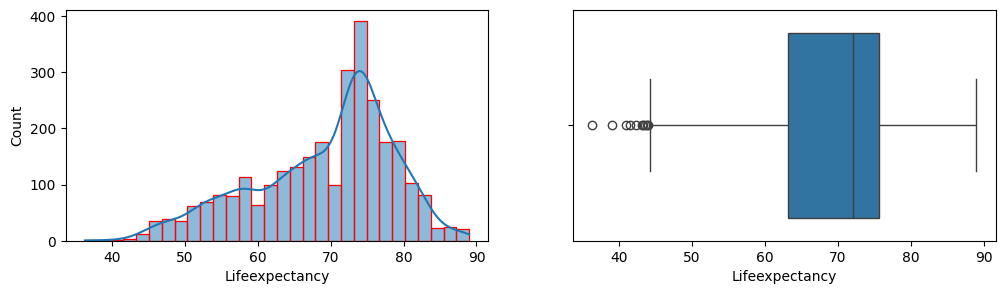

In [416]:
# histogram for life expectancy 
plt.figure(figsize = (12,3)) 
plt.subplot(1,2,1)
sns.histplot(data = df, x = 'Lifeexpectancy', kde = True, edgecolor = 'red') 
plt.subplot(1,2,2) 
sns.boxplot(data = df, x = 'Lifeexpectancy')

In [417]:
df['Country'].value_counts()

Country
Afghanistan              16
Albania                  16
Algeria                  16
Angola                   16
Antigua and Barbuda      16
                         ..
Niue                      1
Palau                     1
Saint Kitts and Nevis     1
San Marino                1
Tuvalu                    1
Name: count, Length: 193, dtype: int64

In [418]:
df['Status'].value_counts()

Status
Developing    2426
Developed      512
Name: count, dtype: int64

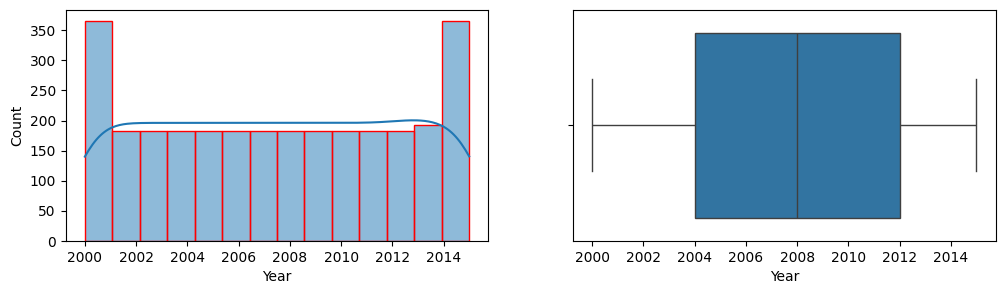

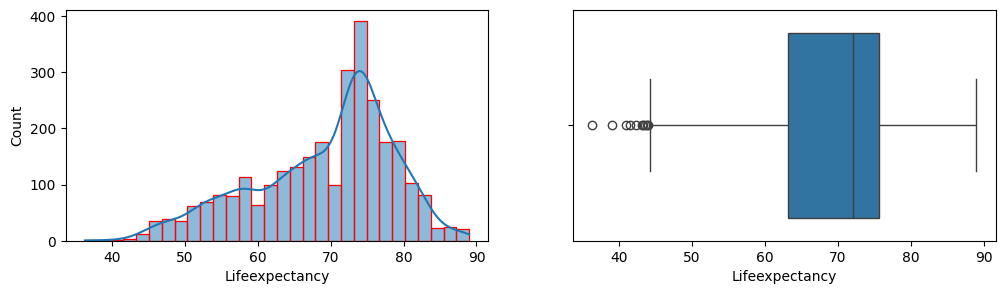

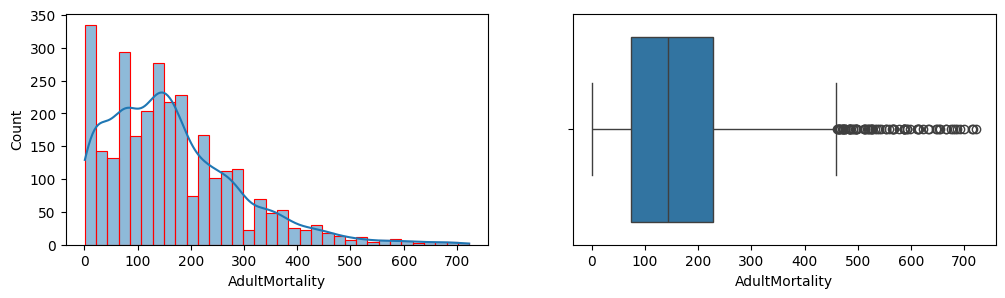

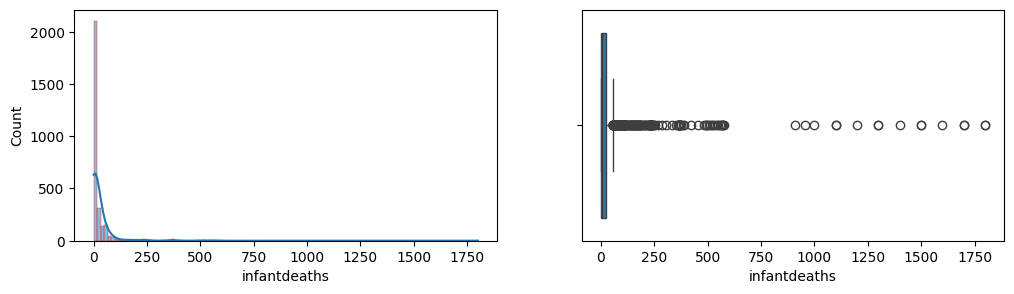

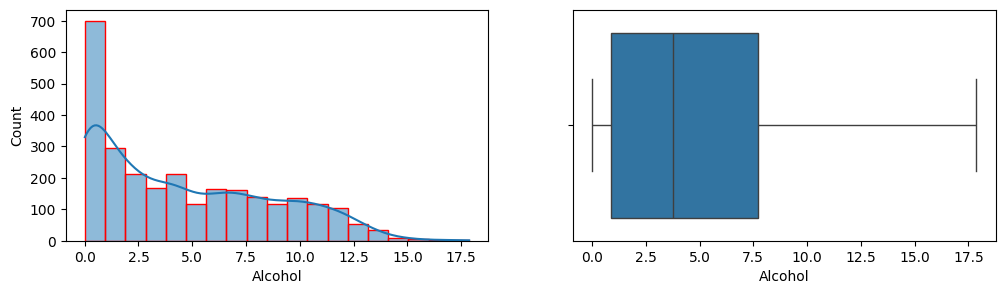

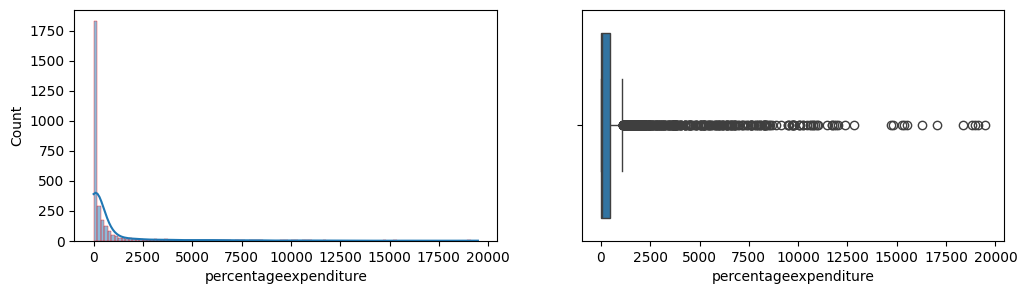

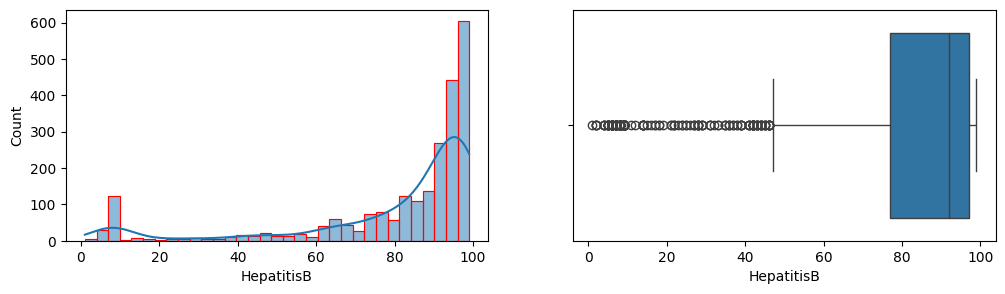

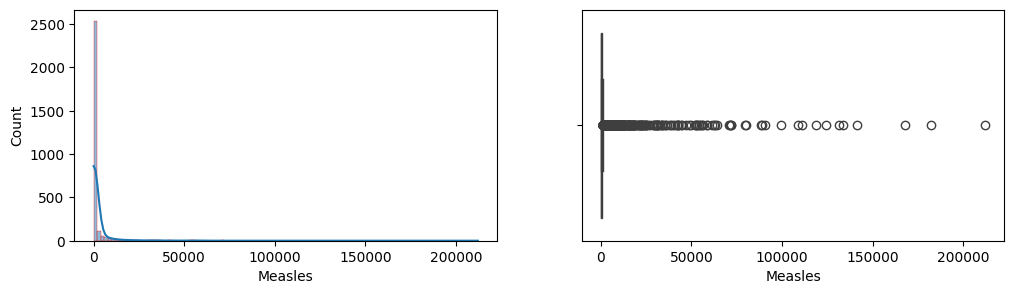

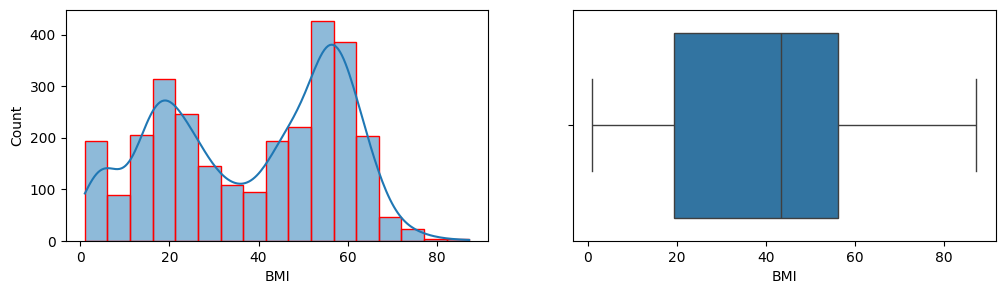

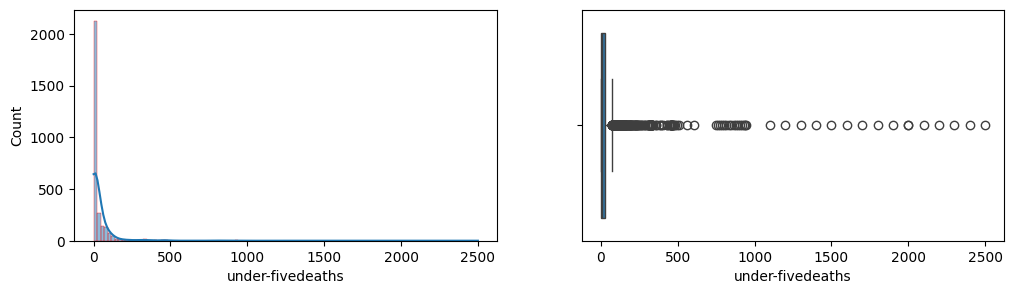

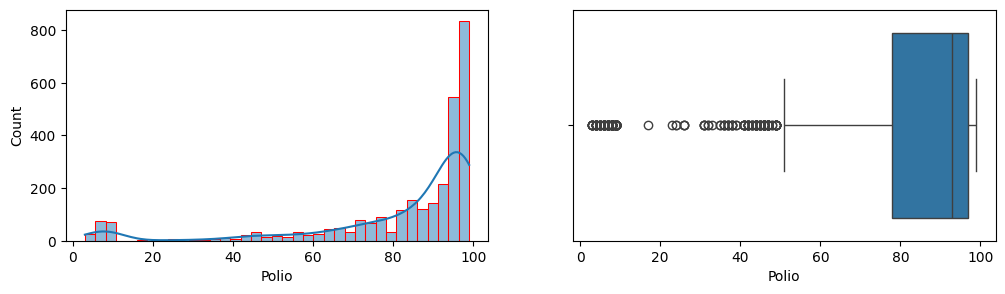

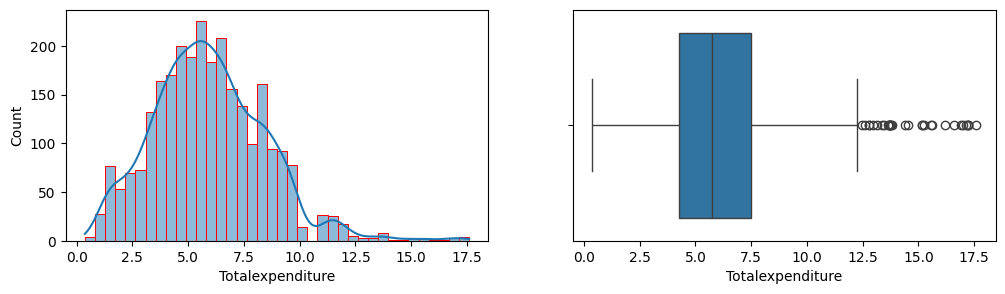

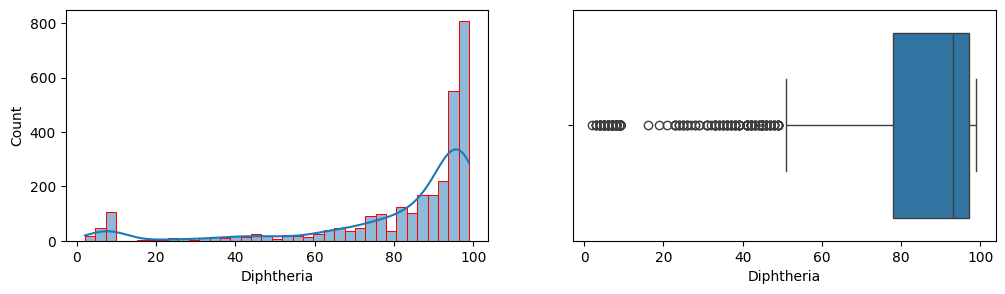

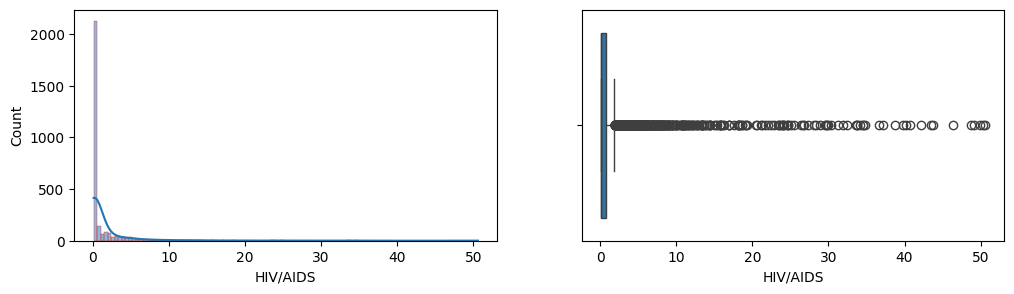

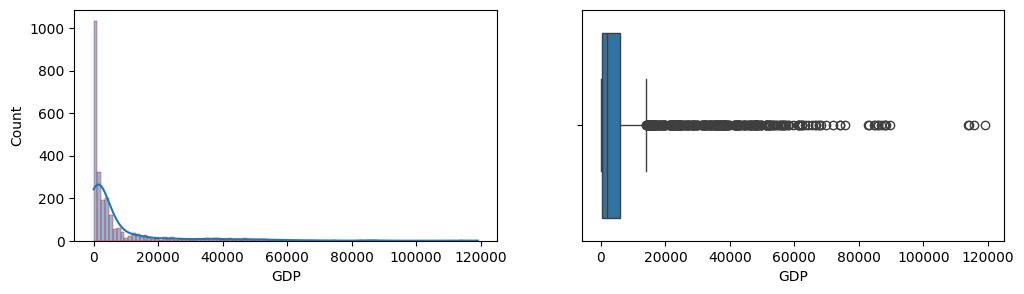

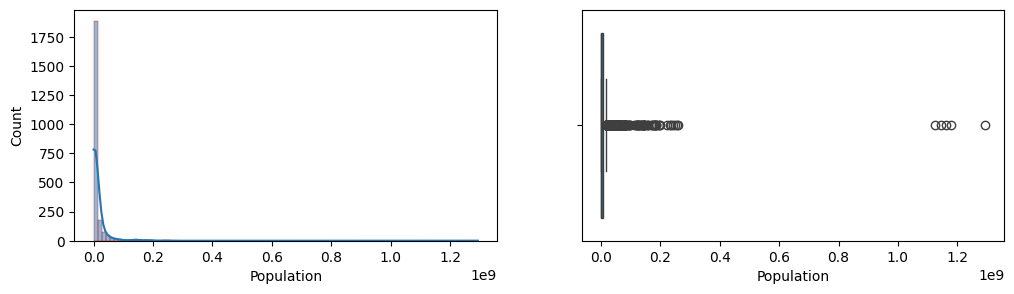

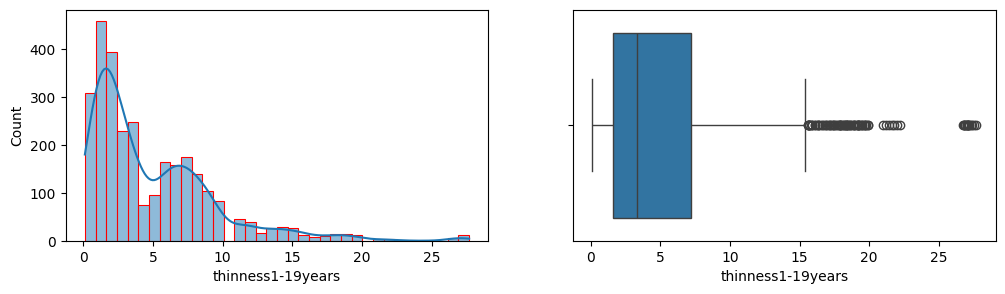

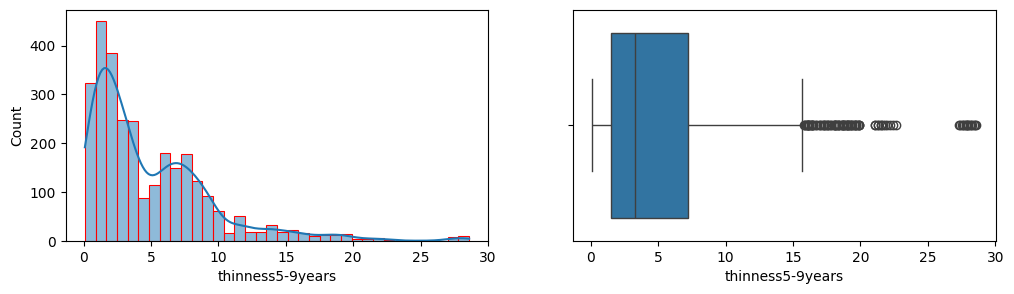

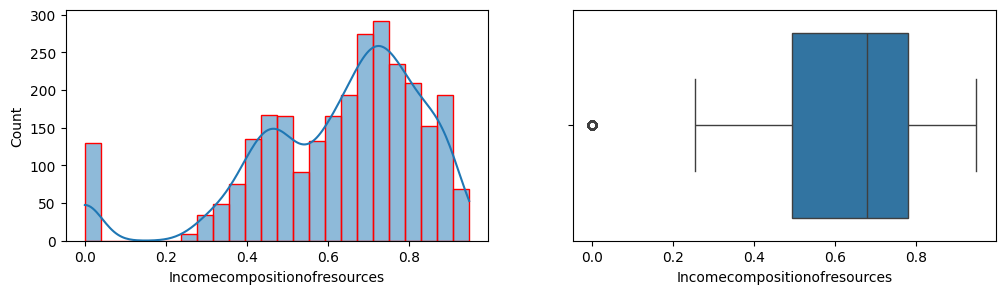

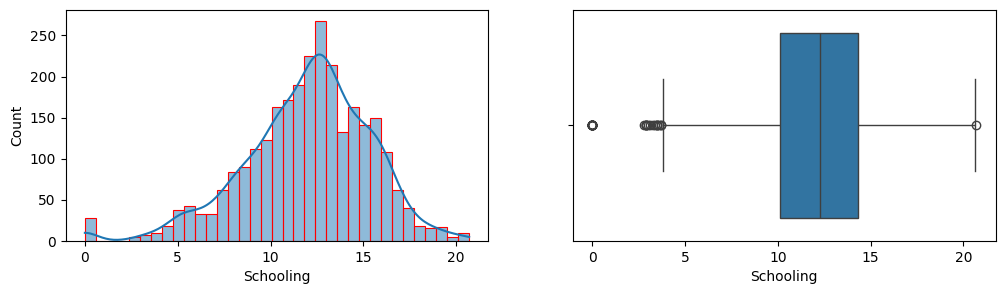

In [419]:
#histogram and boxplot for all numerical columns 
for i in df.columns:
    if df[i].dtype == 'float64' or df[i].dtype == 'int64':
        plt.figure(figsize = (12,3)) 

        plt.subplot(1,2,1) 
        sns.histplot(data = df, x = i, kde = True, edgecolor = 'red') 
        plt.subplot(1,2,2)
        sns.boxplot(data = df, x = i)

# Bivariate Analysis

In [420]:
df.columns

Index(['Country', 'Year', 'Status', 'Lifeexpectancy', 'AdultMortality',
       'infantdeaths', 'Alcohol', 'percentageexpenditure', 'HepatitisB',
       'Measles', 'BMI', 'under-fivedeaths', 'Polio', 'Totalexpenditure',
       'Diphtheria', 'HIV/AIDS', 'GDP', 'Population', 'thinness1-19years',
       'thinness5-9years', 'Incomecompositionofresources', 'Schooling'],
      dtype='str')

<Axes: xlabel='Status', ylabel='Lifeexpectancy'>

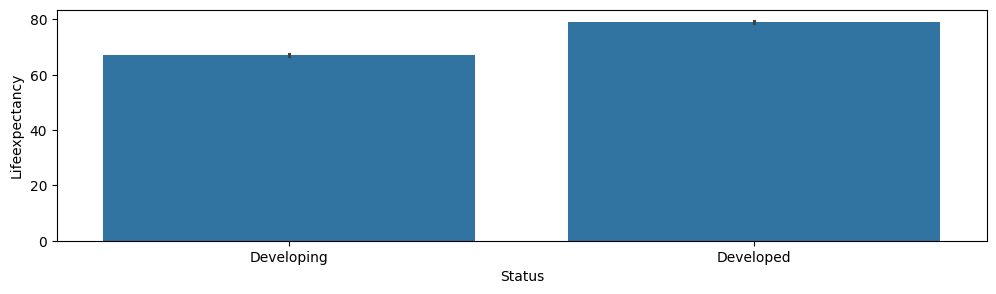

In [421]:
# Life expectancey vs status
plt.figure(figsize = (12,3)) 
sns.barplot(data = df, x = 'Status', y = 'Lifeexpectancy')

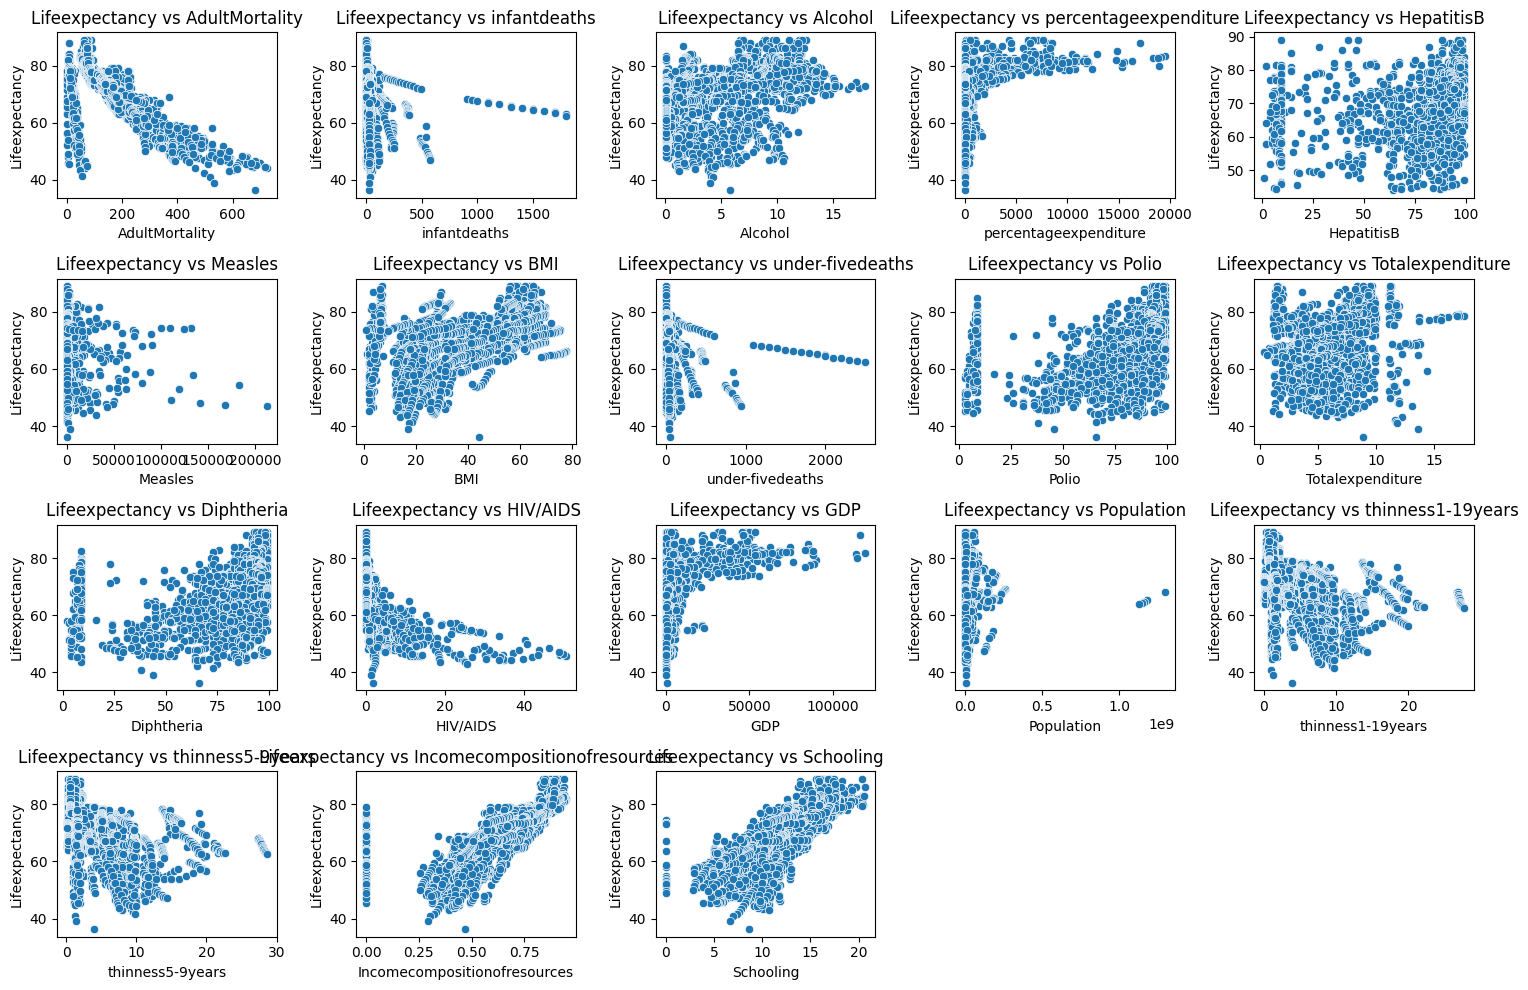

In [422]:
numeric_columns = ['AdultMortality',
       'infantdeaths', 'Alcohol', 'percentageexpenditure', 'HepatitisB',
       'Measles', 'BMI', 'under-fivedeaths', 'Polio', 'Totalexpenditure',
       'Diphtheria', 'HIV/AIDS', 'GDP', 'Population', 'thinness1-19years',
       'thinness5-9years', 'Incomecompositionofresources', 'Schooling']
plt.figure(figsize = (15,10)) 
for i, col in enumerate(numeric_columns, 1): 
    plt.subplot(4,5,i) 
    sns.scatterplot(x = df[col], y = df['Lifeexpectancy'])
    plt.title(f"Lifeexpectancy vs {col}") 
    plt.xlabel(col) 
    plt.ylabel('Lifeexpectancy') 
plt.tight_layout() 
plt.show()

# Msising value Imputation and Outliers Treatment

In [423]:
df.shape

(2938, 22)

In [424]:
df.isnull().sum()

Country                           0
Year                              0
Status                            0
Lifeexpectancy                   10
AdultMortality                   10
infantdeaths                      0
Alcohol                         194
percentageexpenditure             0
HepatitisB                      553
Measles                           0
BMI                              34
under-fivedeaths                  0
Polio                            19
Totalexpenditure                226
Diphtheria                       19
HIV/AIDS                          0
GDP                             448
Population                      652
thinness1-19years                34
thinness5-9years                 34
Incomecompositionofresources    167
Schooling                       163
dtype: int64

In [425]:
from sklearn.impute import SimpleImputer

In [426]:
mean_median_cols = [ 'Alcohol', 
       'BMI',  'Totalexpenditure',
        'thinness1-19years',
       'thinness5-9years', ] 
mode_cols = ['HepatitisB', 'Polio', 'Diphtheria']

In [427]:
mean_imputer = SimpleImputer(strategy = 'mean') 

In [428]:
df[mean_median_cols] = mean_imputer.fit_transform(df[mean_median_cols])

In [429]:
mode_imputer = SimpleImputer(strategy = 'most_frequent') 
df[mode_cols] = mode_imputer.fit_transform(df[mode_cols])

In [430]:
df.isnull().sum().sum()

np.int64(1450)

In [431]:
df.isnull().sum()

Country                           0
Year                              0
Status                            0
Lifeexpectancy                   10
AdultMortality                   10
infantdeaths                      0
Alcohol                           0
percentageexpenditure             0
HepatitisB                        0
Measles                           0
BMI                               0
under-fivedeaths                  0
Polio                             0
Totalexpenditure                  0
Diphtheria                        0
HIV/AIDS                          0
GDP                             448
Population                      652
thinness1-19years                 0
thinness5-9years                  0
Incomecompositionofresources    167
Schooling                       163
dtype: int64

In [432]:
df[df['Lifeexpectancy'].isna()]

,Country,Year,Status,Lifeexpectancy,AdultMortality,infantdeaths,Alcohol,percentageexpenditure,HepatitisB,Measles,...,Polio,Totalexpenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness1-19years,thinness5-9years,Incomecompositionofresources,Schooling
624,Cook Islands,2013,Developing,NaN,NaN,0,0.010000,0.000000,98.0,0,...,98.0,3.58,98.0,0.1,NaN,NaN,0.100000,0.100000,NaN,NaN
769,Dominica,2013,Developing,NaN,NaN,0,0.010000,11.419555,96.0,0,...,96.0,5.58,96.0,0.1,722.756650,NaN,2.700000,2.600000,0.721,12.7
1650,Marshall Islands,2013,Developing,NaN,NaN,0,0.010000,871.878317,8.0,0,...,79.0,17.24,79.0,0.1,3617.752354,NaN,0.100000,0.100000,NaN,0.0
1715,Monaco,2013,Developing,NaN,NaN,0,0.010000,0.000000,99.0,0,...,99.0,4.30,99.0,0.1,NaN,NaN,4.839704,4.870317,NaN,NaN
1812,Nauru,2013,Developing,NaN,NaN,0,0.010000,15.606596,87.0,0,...,87.0,4.65,87.0,0.1,136.183210,NaN,0.100000,0.100000,NaN,9.6
1909,Niue,2013,Developing,NaN,NaN,0,0.010000,0.000000,99.0,0,...,99.0,7.20,99.0,0.1,NaN,NaN,0.100000,0.100000,NaN,NaN
1958,Palau,2013,Developing,NaN,NaN,0,4.602861,344.690631,99.0,0,...,99.0,9.27,99.0,0.1,1932.122370,292.0,0.100000,0.100000,0.779,14.2
2167,Saint Kitts and Nevis,2013,Developing,NaN,NaN,0,8.540000,0.000000,97.0,0,...,96.0,6.14,96.0,0.1,NaN,NaN,3.700000,3.600000,0.749,13.4
2216,San Marino,2013,Developing,NaN,NaN,0,0.010000,0.000000,69.0,0,...,69.0,6.50,69.0,0.1,NaN,NaN,4.839704,4.870317,NaN,15.1
2713,Tuvalu,2013,Developing,NaN,NaN,0,0.010000,78.281203,9.0,0,...,9.0,16.61,9.0,0.1,3542.135890,1819.0,0.200000,0.100000,NaN,0.0


In [433]:
df.dropna(subset = ['Lifeexpectancy'], inplace = True)

In [434]:
df.isna().sum()

Country                           0
Year                              0
Status                            0
Lifeexpectancy                    0
AdultMortality                    0
infantdeaths                      0
Alcohol                           0
percentageexpenditure             0
HepatitisB                        0
Measles                           0
BMI                               0
under-fivedeaths                  0
Polio                             0
Totalexpenditure                  0
Diphtheria                        0
HIV/AIDS                          0
GDP                             443
Population                      644
thinness1-19years                 0
thinness5-9years                  0
Incomecompositionofresources    160
Schooling                       160
dtype: int64

In [435]:
df['GDP'] = df['GDP'].interpolate(method = 'linear', inplace = True) 
df['Population'] = df['Population'].interpolate(method = 'linear', inplace = True)

In [436]:
df.isna().sum()

Country                           0
Year                              0
Status                            0
Lifeexpectancy                    0
AdultMortality                    0
infantdeaths                      0
Alcohol                           0
percentageexpenditure             0
HepatitisB                        0
Measles                           0
BMI                               0
under-fivedeaths                  0
Polio                             0
Totalexpenditure                  0
Diphtheria                        0
HIV/AIDS                          0
GDP                               0
Population                        0
thinness1-19years                 0
thinness5-9years                  0
Incomecompositionofresources    160
Schooling                       160
dtype: int64

In [437]:
df[df['Schooling'].isna()]

,Country,Year,Status,Lifeexpectancy,AdultMortality,infantdeaths,Alcohol,percentageexpenditure,HepatitisB,Measles,...,Polio,Totalexpenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness1-19years,thinness5-9years,Incomecompositionofresources,Schooling
432,Côte d'Ivoire,2015,Developing,53.3,397.0,57,4.602861,0.0,83.0,65,...,81.0,5.93819,83.0,1.9,301.770270,3.744288e+04,5.5,5.5,NaN,NaN
433,Côte d'Ivoire,2014,Developing,52.8,47.0,58,0.010000,0.0,76.0,50,...,76.0,5.72000,76.0,2.0,467.542095,6.840976e+04,5.6,5.6,NaN,NaN
434,Côte d'Ivoire,2013,Developing,52.3,412.0,59,3.150000,0.0,8.0,48,...,79.0,5.81000,8.0,2.4,633.313920,9.937665e+04,5.8,5.7,NaN,NaN
435,Côte d'Ivoire,2012,Developing,52.0,415.0,59,3.240000,0.0,82.0,137,...,83.0,6.14000,82.0,2.9,799.085745,1.303435e+05,5.9,5.9,NaN,NaN
436,Côte d'Ivoire,2011,Developing,51.7,419.0,60,3.130000,0.0,62.0,628,...,58.0,6.42000,62.0,3.3,964.857569,1.613104e+05,6.1,6.0,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2805,United States of America,2004,Developed,77.5,111.0,28,8.480000,0.0,92.0,37,...,92.0,15.14000,96.0,0.1,14284.681880,6.950344e+06,0.7,0.6,NaN,NaN
2806,United States of America,2003,Developed,77.2,114.0,28,8.400000,0.0,92.0,56,...,91.0,15.60000,96.0,0.1,14532.713998,6.246586e+06,0.7,0.6,NaN,NaN
2807,United States of America,2002,Developed,77.0,115.0,28,8.330000,0.0,88.0,41,...,9.0,14.55000,94.0,0.1,14780.746116,5.542827e+06,0.8,0.6,NaN,NaN
2808,United States of America,2001,Developed,76.9,115.0,28,8.250000,0.0,89.0,116,...,89.0,13.73000,94.0,0.1,15028.778234,4.839069e+06,0.8,0.6,NaN,NaN


In [438]:
df['Incomecompositionofresources'] = df['Incomecompositionofresources'].fillna(df.groupby('Country')['Incomecompositionofresources'].transform('median')) 
df['Schooling'] = df['Schooling'].fillna(df.groupby('Country')['Schooling'].transform('median')) 


In [439]:
df['Incomecompositionofresources'] = df['Incomecompositionofresources'].fillna(df.groupby('Status')['Incomecompositionofresources'].transform('median')) 
df['Schooling'] = df['Schooling'].fillna(df.groupby('Status')['Schooling'].transform('median'), inplace = True)

In [440]:
df.isna().sum()

Country                         0
Year                            0
Status                          0
Lifeexpectancy                  0
AdultMortality                  0
infantdeaths                    0
Alcohol                         0
percentageexpenditure           0
HepatitisB                      0
Measles                         0
BMI                             0
under-fivedeaths                0
Polio                           0
Totalexpenditure                0
Diphtheria                      0
HIV/AIDS                        0
GDP                             0
Population                      0
thinness1-19years               0
thinness5-9years                0
Incomecompositionofresources    0
Schooling                       0
dtype: int64

In [441]:
df.shape

(2928, 22)

In [442]:
df['Country'].unique().tolist()

['Afghanistan',
 'Albania',
 'Algeria',
 'Angola',
 'Antigua and Barbuda',
 'Argentina',
 'Armenia',
 'Australia',
 'Austria',
 'Azerbaijan',
 'Bahamas',
 'Bahrain',
 'Bangladesh',
 'Barbados',
 'Belarus',
 'Belgium',
 'Belize',
 'Benin',
 'Bhutan',
 'Bolivia (Plurinational State of)',
 'Bosnia and Herzegovina',
 'Botswana',
 'Brazil',
 'Brunei Darussalam',
 'Bulgaria',
 'Burkina Faso',
 'Burundi',
 "Côte d'Ivoire",
 'Cabo Verde',
 'Cambodia',
 'Cameroon',
 'Canada',
 'Central African Republic',
 'Chad',
 'Chile',
 'China',
 'Colombia',
 'Comoros',
 'Congo',
 'Costa Rica',
 'Croatia',
 'Cuba',
 'Cyprus',
 'Czechia',
 "Democratic People's Republic of Korea",
 'Democratic Republic of the Congo',
 'Denmark',
 'Djibouti',
 'Dominican Republic',
 'Ecuador',
 'Egypt',
 'El Salvador',
 'Equatorial Guinea',
 'Eritrea',
 'Estonia',
 'Ethiopia',
 'Fiji',
 'Finland',
 'France',
 'Gabon',
 'Gambia',
 'Georgia',
 'Germany',
 'Ghana',
 'Greece',
 'Grenada',
 'Guatemala',
 'Guinea',
 'Guinea-Bissau',

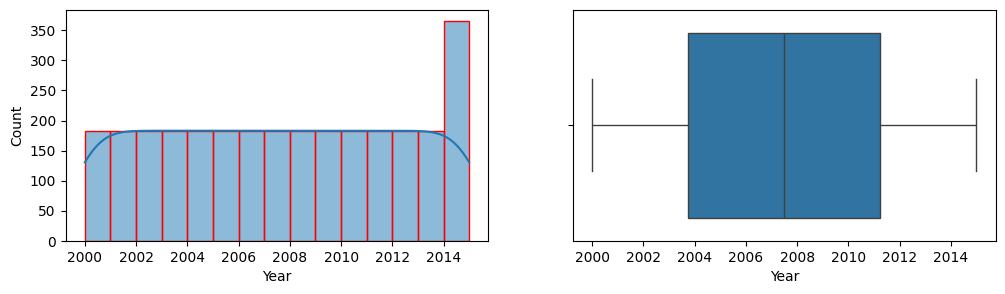

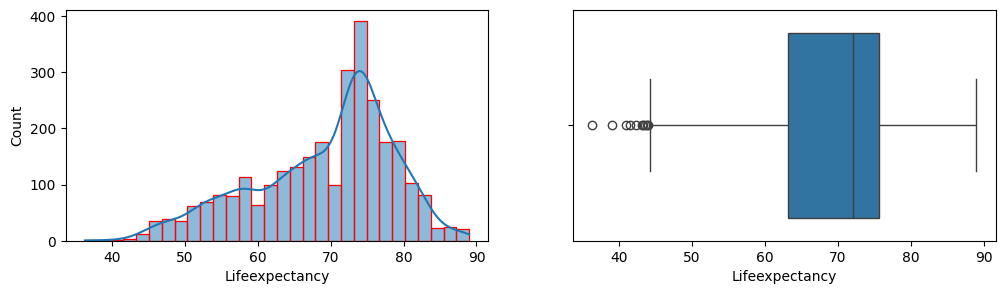

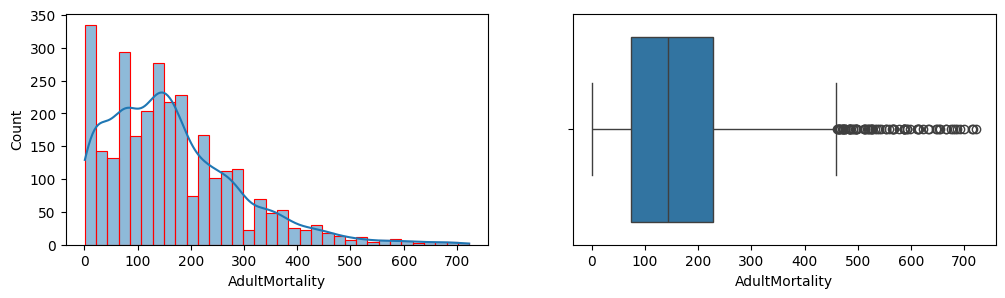

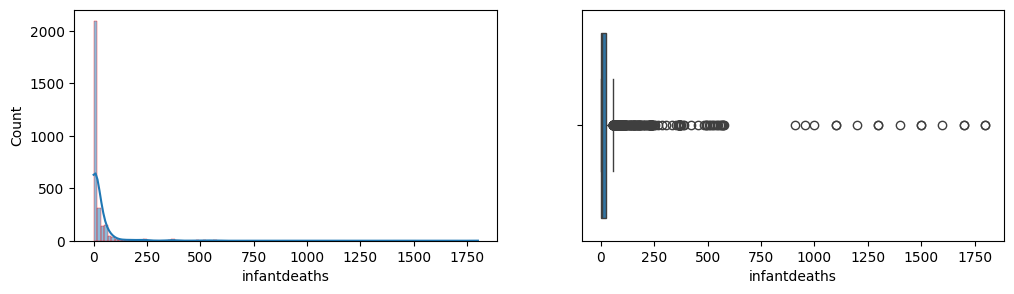

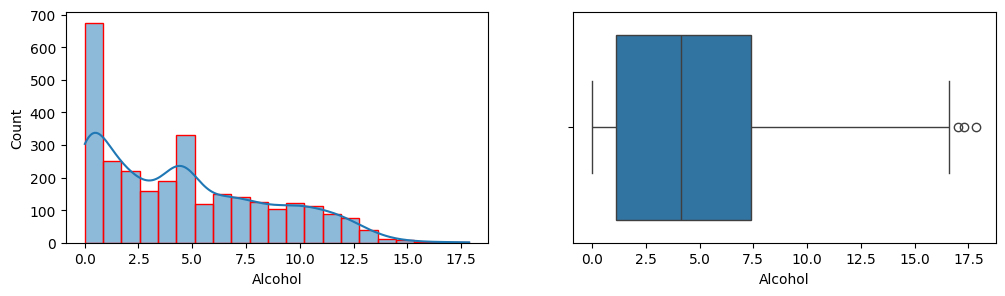

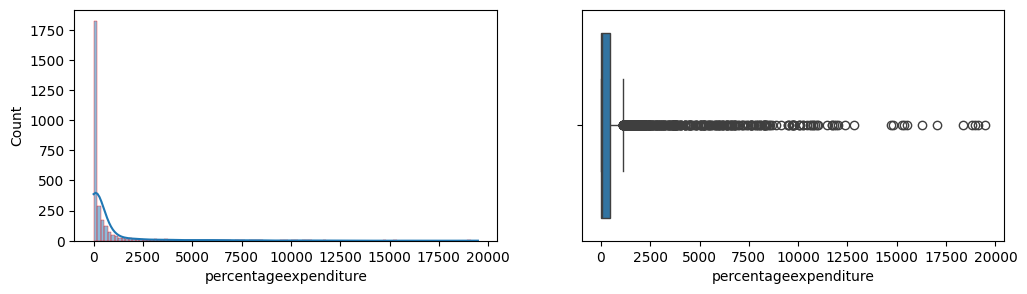

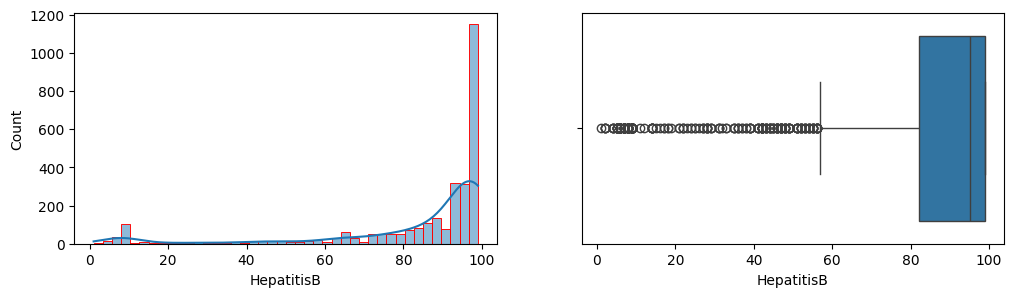

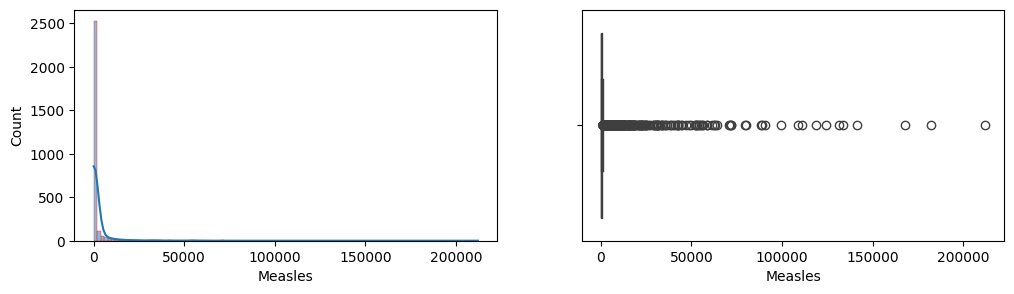

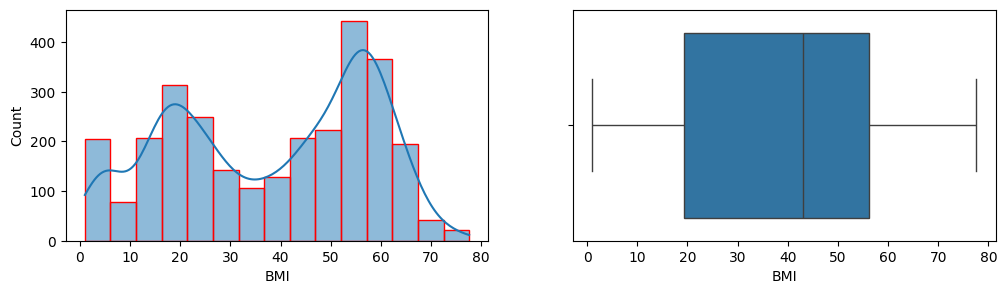

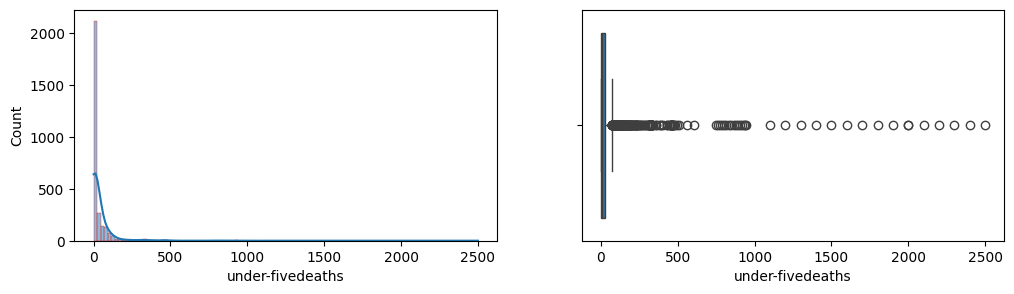

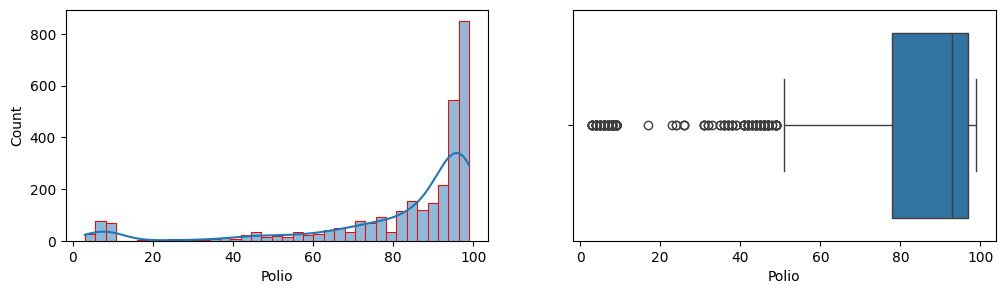

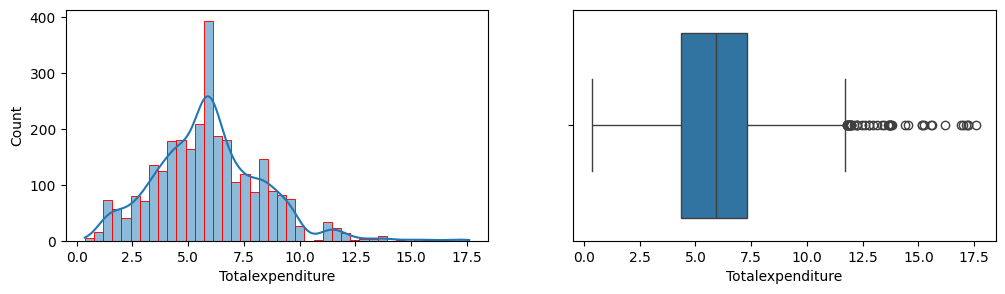

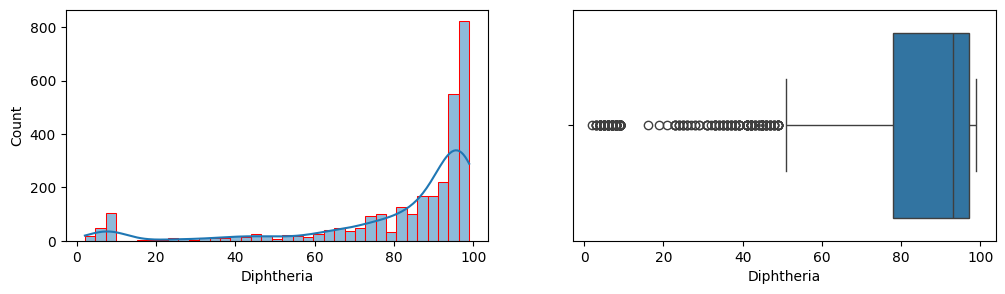

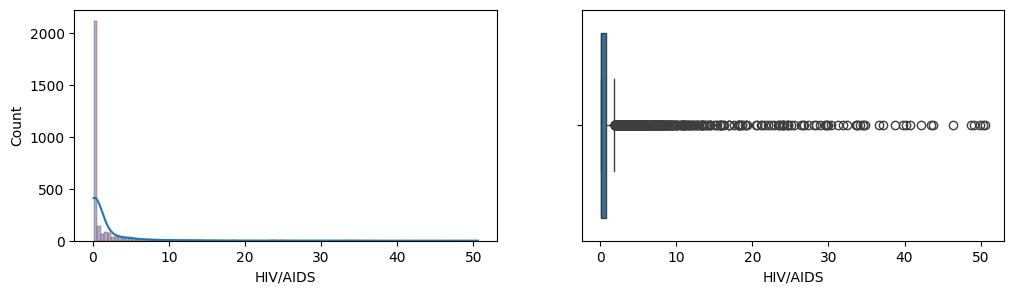

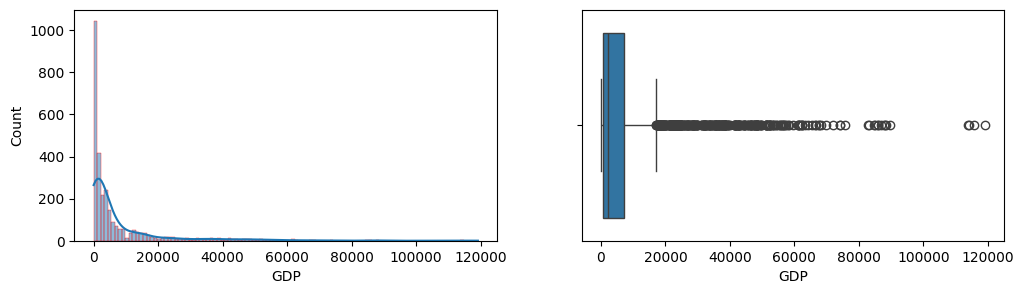

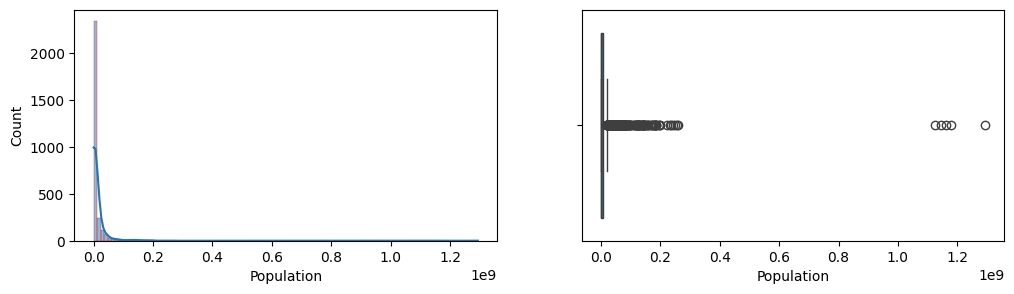

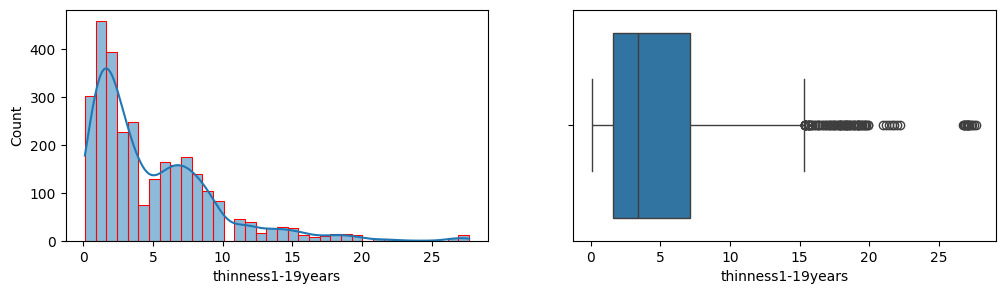

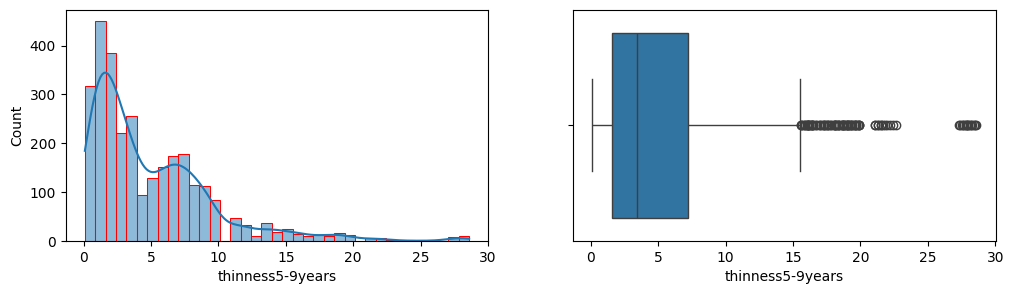

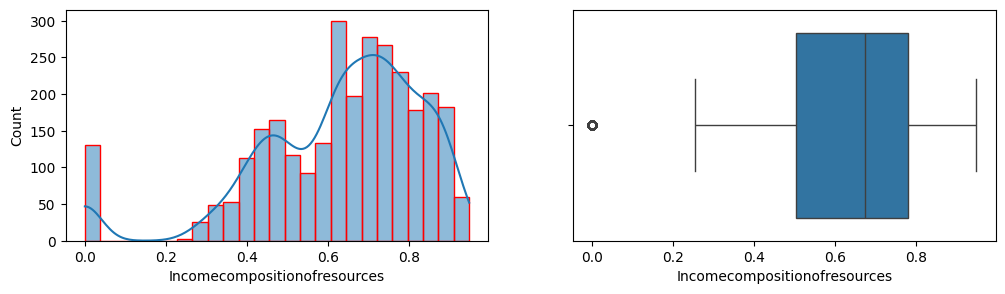

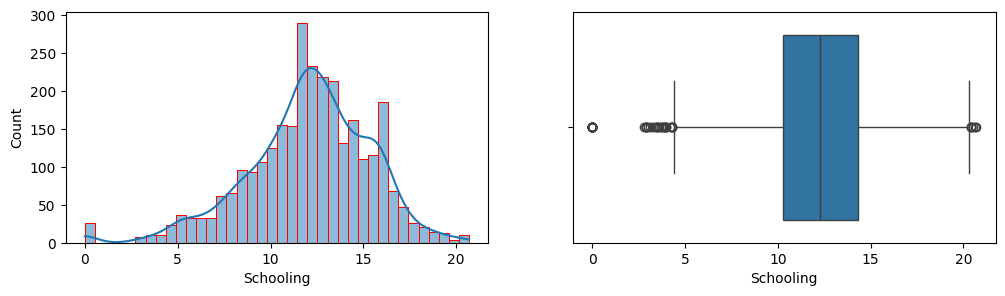

In [443]:
#histogram for all numerical columns 
for i in df.columns:
    if df[i].dtype == 'float64' or df[i].dtype == 'int64':
        plt.figure(figsize = (12,3)) 
        plt.subplot(1,2,1) 
        sns.histplot(data = df, x = i , kde = True, edgecolor = 'red') 
        plt.subplot(1,2,2) 
        sns.boxplot(data = df, x = i)

# Handling Outliers

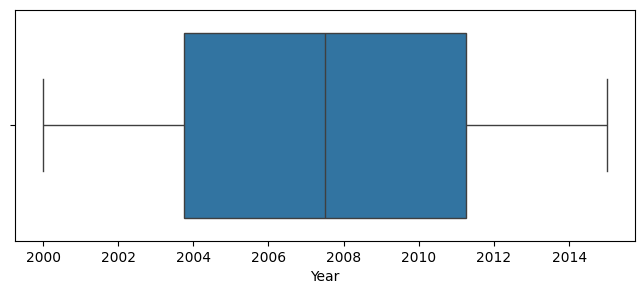

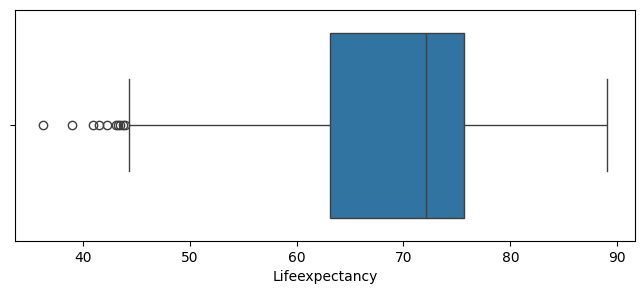

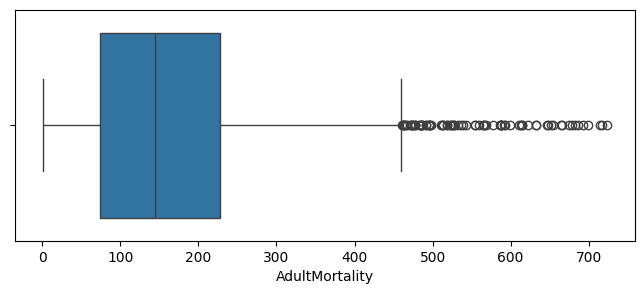

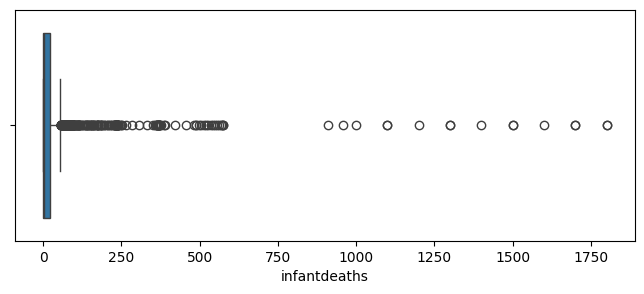

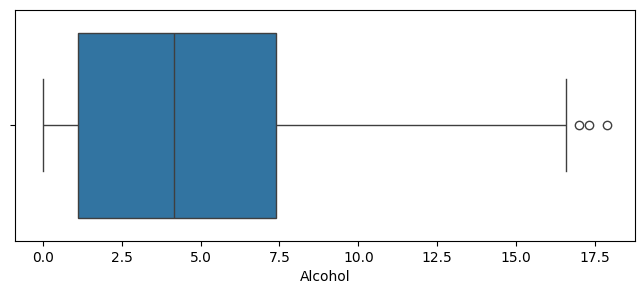

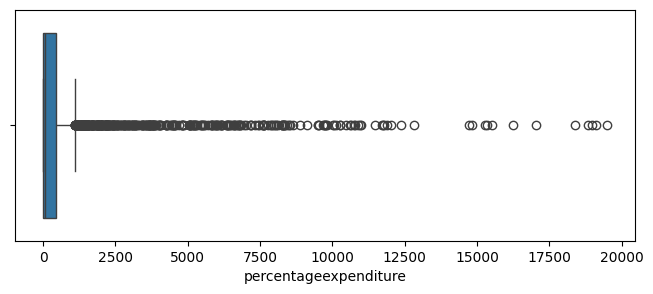

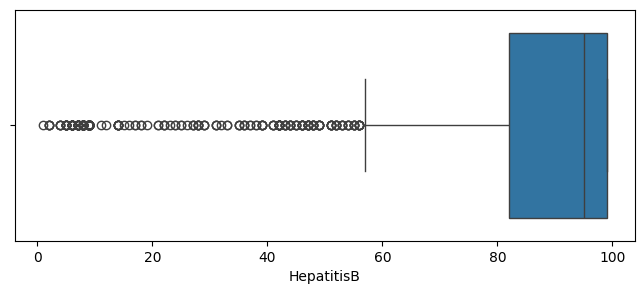

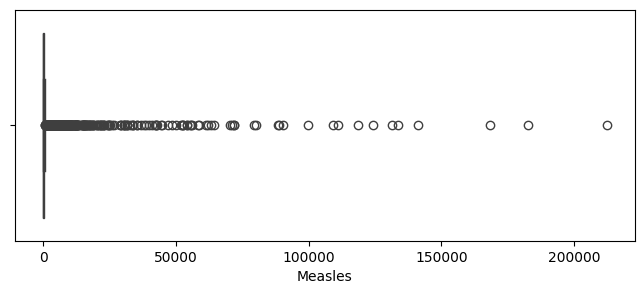

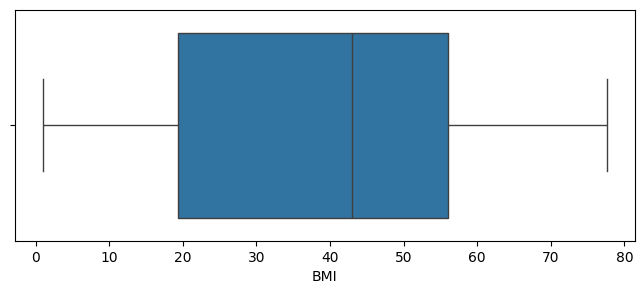

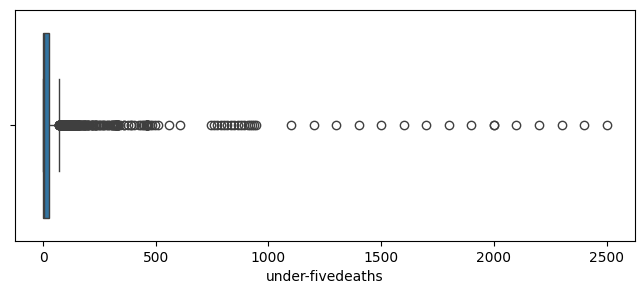

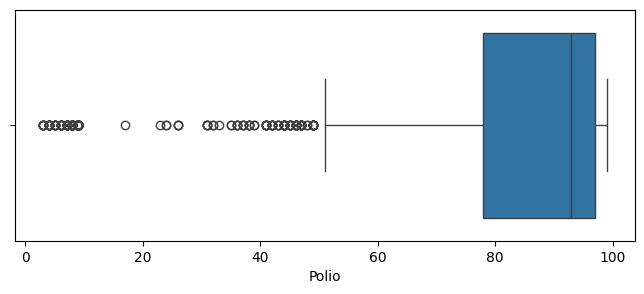

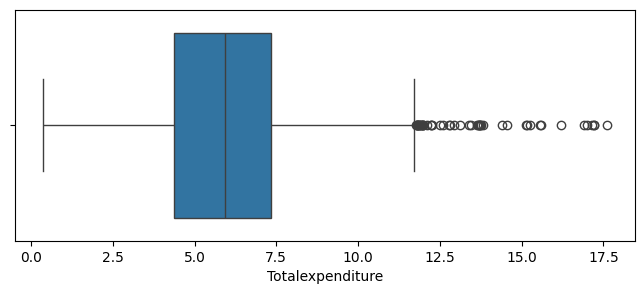

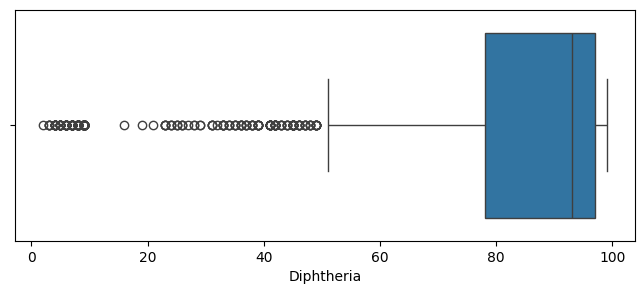

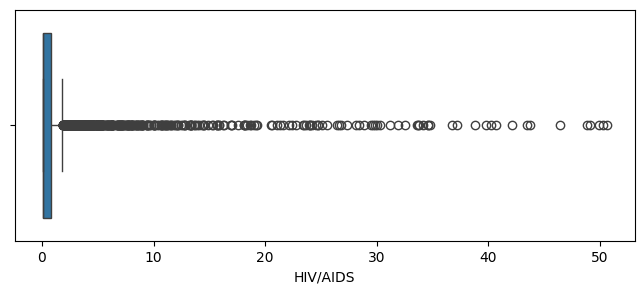

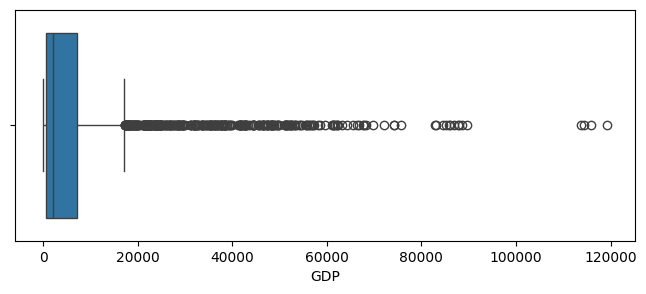

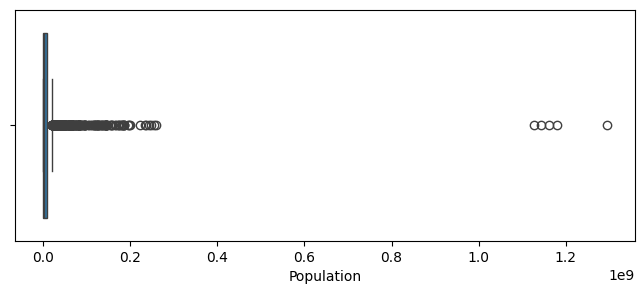

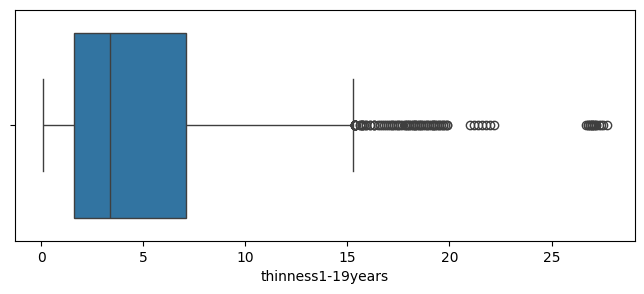

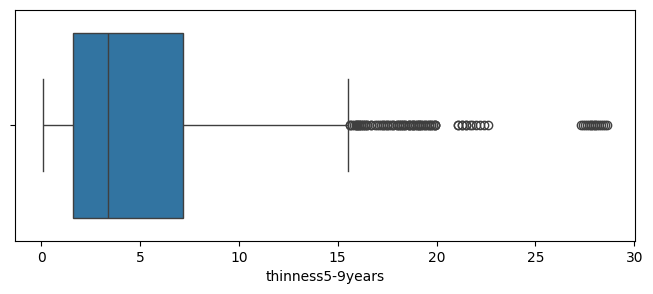

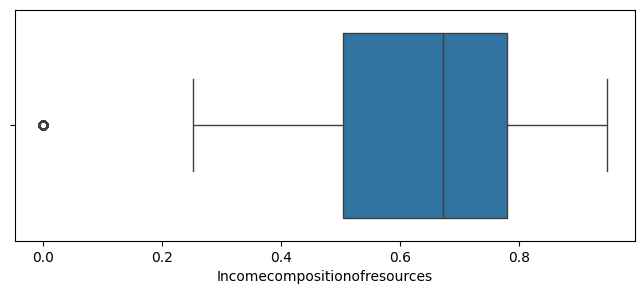

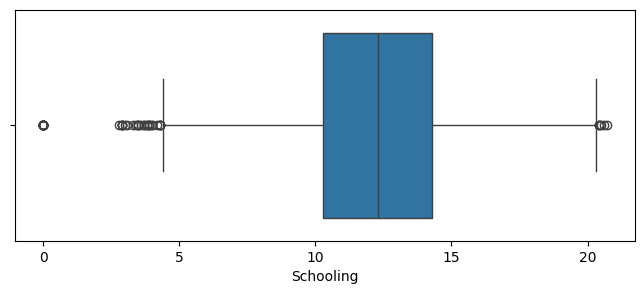

In [444]:
for i in df.columns:
    if df[i].dtype == 'float64' or df[i].dtype == 'int64': 
        plt.figure(figsize = (8,3)) 
        sns.boxplot(data = df, x = i)

In [445]:
df.columns

Index(['Country', 'Year', 'Status', 'Lifeexpectancy', 'AdultMortality',
       'infantdeaths', 'Alcohol', 'percentageexpenditure', 'HepatitisB',
       'Measles', 'BMI', 'under-fivedeaths', 'Polio', 'Totalexpenditure',
       'Diphtheria', 'HIV/AIDS', 'GDP', 'Population', 'thinness1-19years',
       'thinness5-9years', 'Incomecompositionofresources', 'Schooling'],
      dtype='str')

In [446]:
cols_to_handle_outliers = ['AdultMortality',
       'infantdeaths', 'Alcohol', 'percentageexpenditure', 'HepatitisB',
       'Measles', 'BMI', 'under-fivedeaths', 'Polio', 'Totalexpenditure',
       'Diphtheria', 'HIV/AIDS', 'GDP', 'Population', 'thinness1-19years',
       'thinness5-9years', 'Incomecompositionofresources', 'Schooling' ]  
for col_name in cols_to_handle_outliers:
    q1 = df[col_name].quantile(0.25) 
    q3 = df[col_name].quantile(0.75) 
    iqr = q3 - q1 
    lower_bound = q1 - 1.5 * iqr 
    upper_bound = q3 + 1.5 * iqr 
    df[col_name] = np.where((df[col_name] > upper_bound) | (df[col_name] < lower_bound), np.mean(df[col_name]), df[col_name]) 

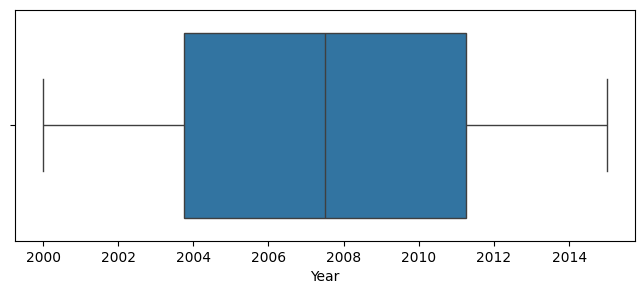

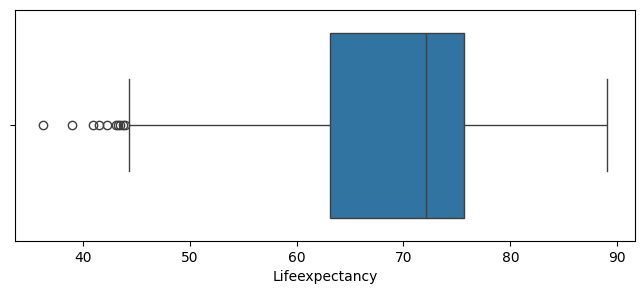

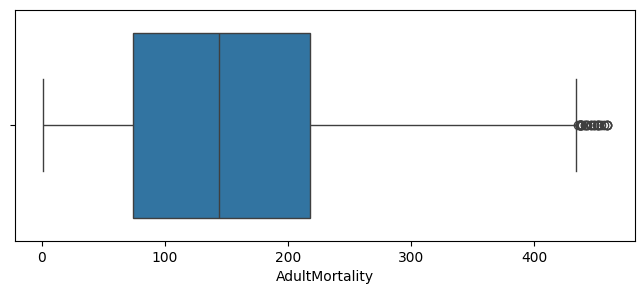

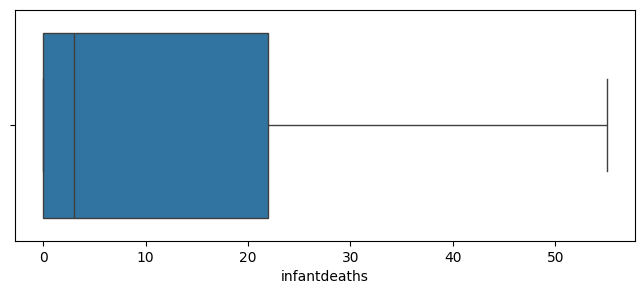

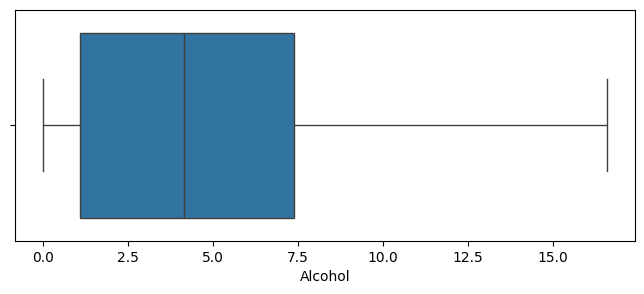

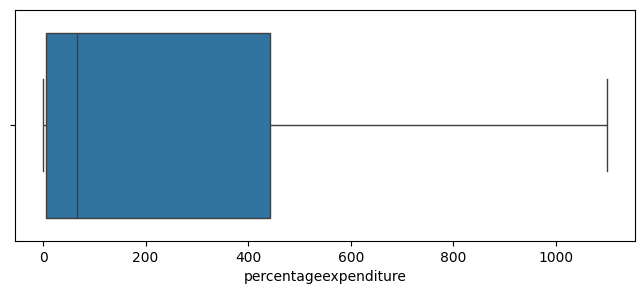

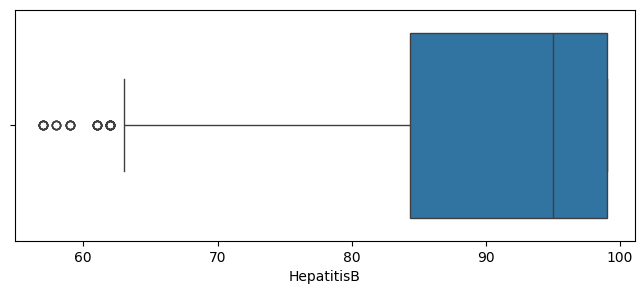

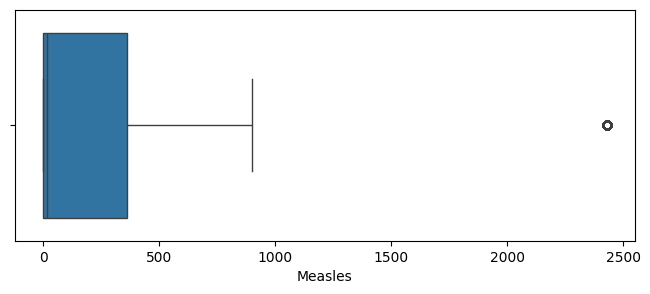

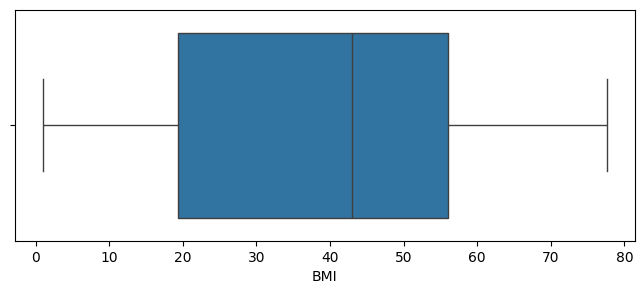

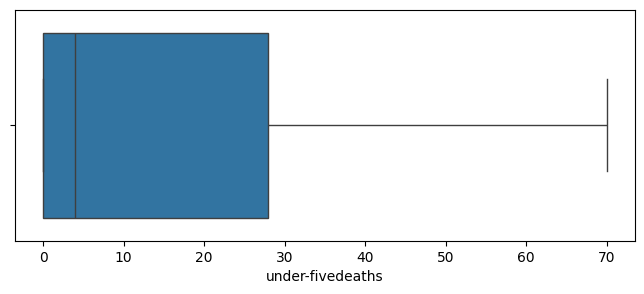

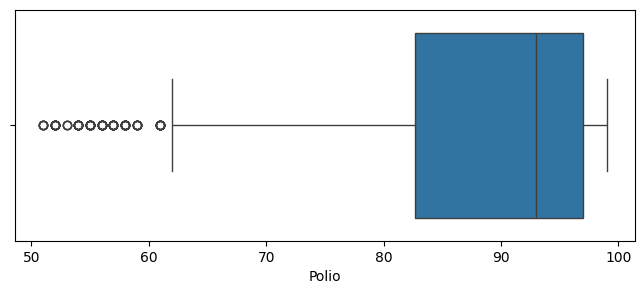

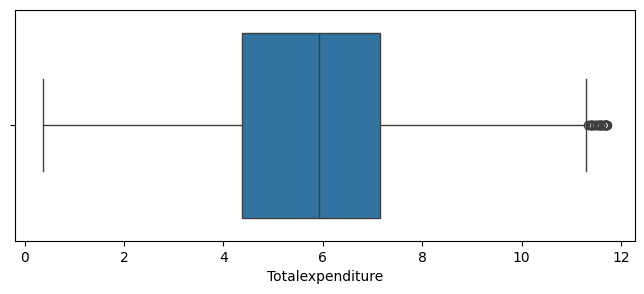

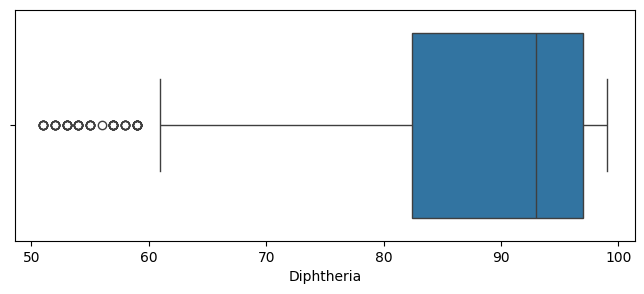

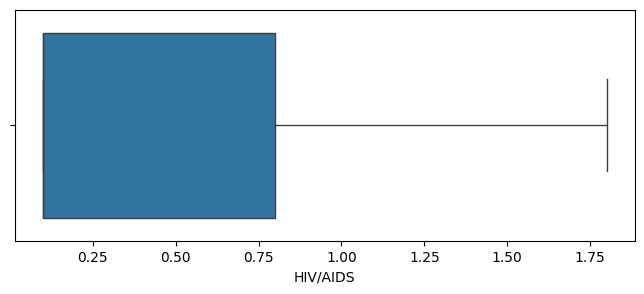

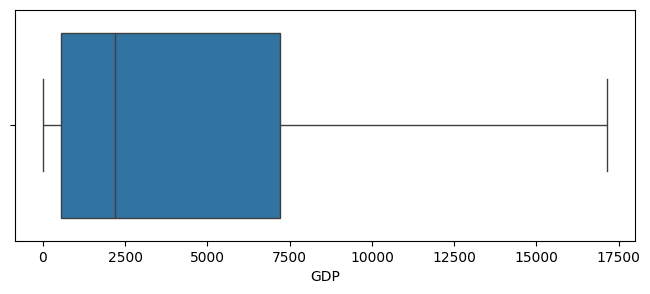

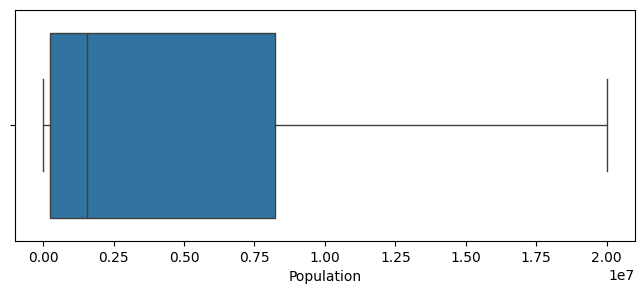

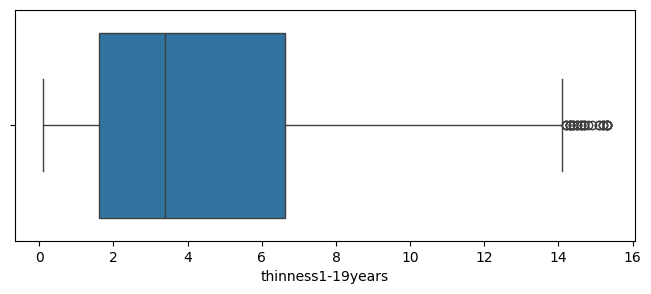

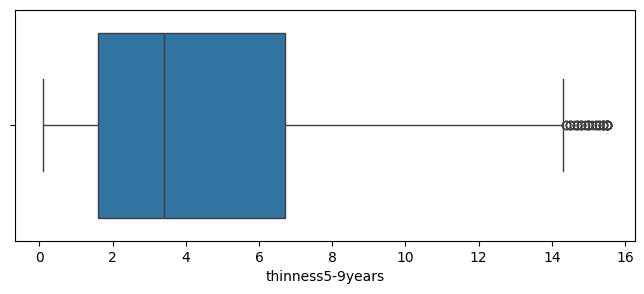

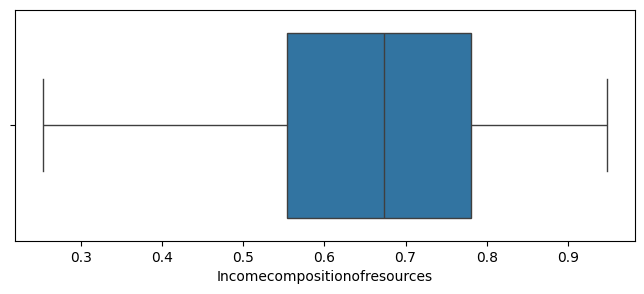

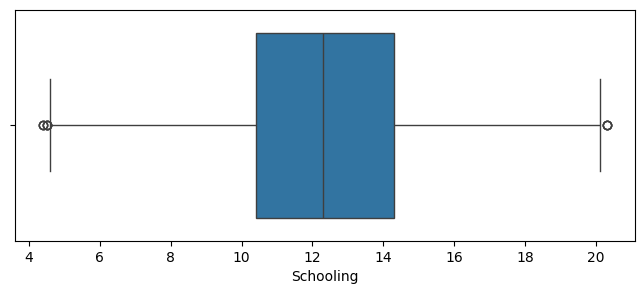

In [447]:
for i in df.columns:
    if df[i].dtype == 'float64' or df[i].dtype == 'int64': 
        plt.figure(figsize = (8,3)) 
        sns.boxplot(data = df, x = i)

# Data Encoding

In [448]:
df.head()

,Country,Year,Status,Lifeexpectancy,AdultMortality,infantdeaths,Alcohol,percentageexpenditure,HepatitisB,Measles,...,Polio,Totalexpenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness1-19years,thinness5-9years,Incomecompositionofresources,Schooling
0,Afghanistan,2015,Developing,65.0,263.0,30.407445,0.01,71.279624,65.0,2427.855874,...,82.655055,8.16,65.0,0.1,584.259210,1.231209e+07,4.850502,4.881301,0.479,10.1
1,Afghanistan,2014,Developing,59.9,271.0,30.407445,0.01,73.523582,62.0,492.000000,...,58.000000,8.18,62.0,0.1,612.696514,3.275820e+05,4.850502,4.881301,0.476,10.0
2,Afghanistan,2013,Developing,59.9,268.0,30.407445,0.01,73.219243,64.0,430.000000,...,62.000000,8.13,64.0,0.1,631.744976,1.231209e+07,4.850502,4.881301,0.470,9.9
3,Afghanistan,2012,Developing,59.5,272.0,30.407445,0.01,78.184215,67.0,2427.855874,...,67.000000,8.52,67.0,0.1,669.959000,3.696958e+06,4.850502,4.881301,0.463,9.8
4,Afghanistan,2011,Developing,59.2,275.0,30.407445,0.01,7.097109,68.0,2427.855874,...,68.000000,7.87,68.0,0.1,63.537231,2.978599e+06,4.850502,4.881301,0.454,9.5


In [449]:
df.info()

<class 'pandas.DataFrame'>
Index: 2928 entries, 0 to 2937
Data columns (total 22 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Country                       2928 non-null   str    
 1   Year                          2928 non-null   int64  
 2   Status                        2928 non-null   str    
 3   Lifeexpectancy                2928 non-null   float64
 4   AdultMortality                2928 non-null   float64
 5   infantdeaths                  2928 non-null   float64
 6   Alcohol                       2928 non-null   float64
 7   percentageexpenditure         2928 non-null   float64
 8   HepatitisB                    2928 non-null   float64
 9   Measles                       2928 non-null   float64
 10  BMI                           2928 non-null   float64
 11  under-fivedeaths              2928 non-null   float64
 12  Polio                         2928 non-null   float64
 13  Totalexpenditure   

In [450]:
df.nunique()

Country                          183
Year                              16
Status                             2
Lifeexpectancy                   362
AdultMortality                   358
infantdeaths                      57
Alcohol                         1075
percentageexpenditure           1936
HepatitisB                        40
Measles                          426
BMI                              603
under-fivedeaths                  71
Polio                             46
Totalexpenditure                 774
Diphtheria                        46
HIV/AIDS                          19
GDP                             2581
Population                      2558
thinness1-19years                143
thinness5-9years                 146
Incomecompositionofresources     625
Schooling                        155
dtype: int64

In [451]:
df['Status'].value_counts()

Status
Developing    2416
Developed      512
Name: count, dtype: int64

In [452]:
#Binary encoding 
df['Status'] = df['Status'].map({'Developed':1, 'Developing':0}) 
df['Status'] = df['Status'].astype(int)

# Target Encoding

In [453]:
category_means = df.groupby('Country')['Lifeexpectancy'].mean().round(2).to_dict() 
category_means

{'Afghanistan': 58.19,
 'Albania': 75.16,
 'Algeria': 73.62,
 'Angola': 49.02,
 'Antigua and Barbuda': 75.06,
 'Argentina': 75.16,
 'Armenia': 73.4,
 'Australia': 81.81,
 'Austria': 81.48,
 'Azerbaijan': 70.73,
 'Bahamas': 74.29,
 'Bahrain': 75.72,
 'Bangladesh': 69.3,
 'Barbados': 74.36,
 'Belarus': 69.91,
 'Belgium': 80.68,
 'Belize': 69.27,
 'Benin': 57.57,
 'Bhutan': 66.16,
 'Bolivia (Plurinational State of)': 67.71,
 'Bosnia and Herzegovina': 75.97,
 'Botswana': 56.05,
 'Brazil': 73.38,
 'Brunei Darussalam': 76.49,
 'Bulgaria': 72.85,
 'Burkina Faso': 55.64,
 'Burundi': 55.54,
 'Cabo Verde': 72.52,
 'Cambodia': 64.34,
 'Cameroon': 54.02,
 'Canada': 81.69,
 'Central African Republic': 48.51,
 'Chad': 50.39,
 'Chile': 79.45,
 'China': 74.26,
 'Colombia': 73.29,
 'Comoros': 61.58,
 'Congo': 59.04,
 'Costa Rica': 78.59,
 'Croatia': 76.12,
 'Cuba': 77.97,
 'Cyprus': 79.68,
 'Czechia': 76.77,
 "Côte d'Ivoire": 50.39,
 "Democratic People's Republic of Korea": 69.19,
 'Democratic Republic

In [454]:
df['Country'] = df['Country'].map(category_means)

In [455]:
df.head()

,Country,Year,Status,Lifeexpectancy,AdultMortality,infantdeaths,Alcohol,percentageexpenditure,HepatitisB,Measles,...,Polio,Totalexpenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness1-19years,thinness5-9years,Incomecompositionofresources,Schooling
0,58.19,2015,0,65.0,263.0,30.407445,0.01,71.279624,65.0,2427.855874,...,82.655055,8.16,65.0,0.1,584.259210,1.231209e+07,4.850502,4.881301,0.479,10.1
1,58.19,2014,0,59.9,271.0,30.407445,0.01,73.523582,62.0,492.000000,...,58.000000,8.18,62.0,0.1,612.696514,3.275820e+05,4.850502,4.881301,0.476,10.0
2,58.19,2013,0,59.9,268.0,30.407445,0.01,73.219243,64.0,430.000000,...,62.000000,8.13,64.0,0.1,631.744976,1.231209e+07,4.850502,4.881301,0.470,9.9
3,58.19,2012,0,59.5,272.0,30.407445,0.01,78.184215,67.0,2427.855874,...,67.000000,8.52,67.0,0.1,669.959000,3.696958e+06,4.850502,4.881301,0.463,9.8
4,58.19,2011,0,59.2,275.0,30.407445,0.01,7.097109,68.0,2427.855874,...,68.000000,7.87,68.0,0.1,63.537231,2.978599e+06,4.850502,4.881301,0.454,9.5


In [456]:
df.info()

<class 'pandas.DataFrame'>
Index: 2928 entries, 0 to 2937
Data columns (total 22 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Country                       2928 non-null   float64
 1   Year                          2928 non-null   int64  
 2   Status                        2928 non-null   int64  
 3   Lifeexpectancy                2928 non-null   float64
 4   AdultMortality                2928 non-null   float64
 5   infantdeaths                  2928 non-null   float64
 6   Alcohol                       2928 non-null   float64
 7   percentageexpenditure         2928 non-null   float64
 8   HepatitisB                    2928 non-null   float64
 9   Measles                       2928 non-null   float64
 10  BMI                           2928 non-null   float64
 11  under-fivedeaths              2928 non-null   float64
 12  Polio                         2928 non-null   float64
 13  Totalexpenditure   

<Axes: >

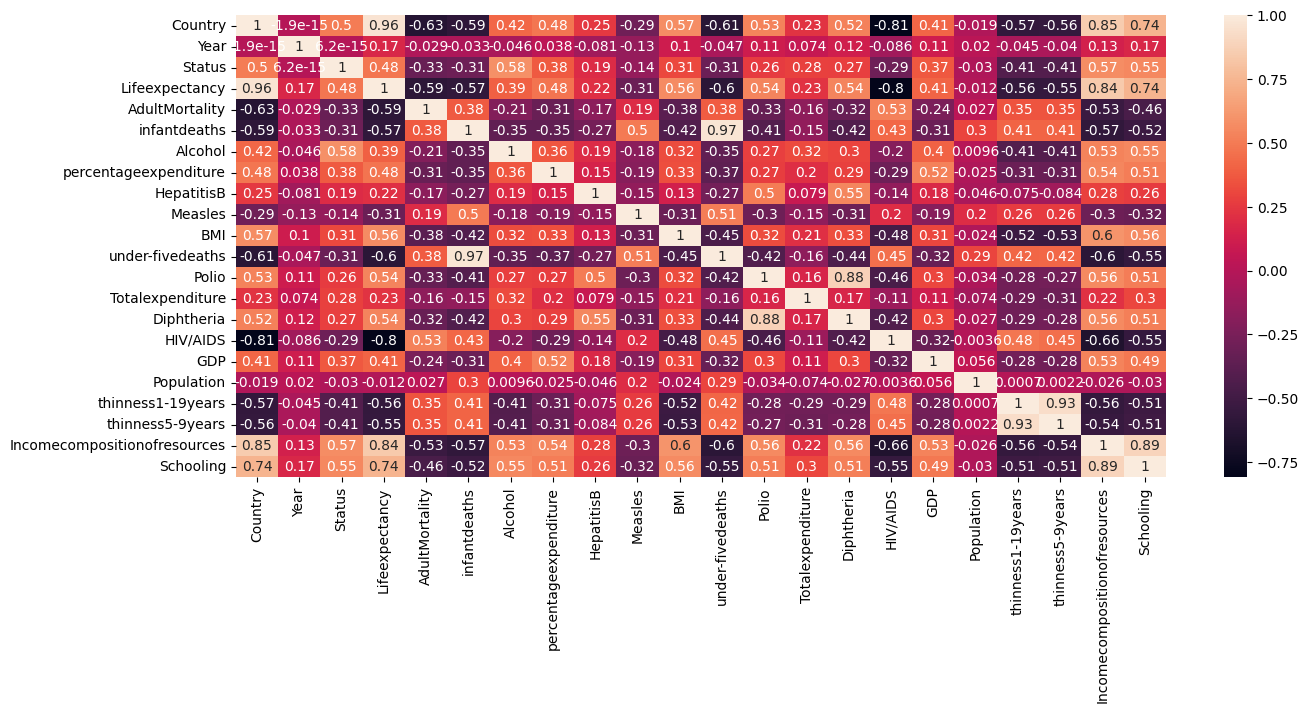

In [457]:
plt.figure(figsize = (15,6)) 
sns.heatmap(df.corr(), annot = True)

# Model Building

In [458]:
df.drop(['Year'], axis = 1, inplace = True)

In [459]:
df

,Country,Status,Lifeexpectancy,AdultMortality,infantdeaths,Alcohol,percentageexpenditure,HepatitisB,Measles,BMI,...,Polio,Totalexpenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness1-19years,thinness5-9years,Incomecompositionofresources,Schooling
0,58.19,0,65.0,263.000000,30.407445,0.01,71.279624,65.000000,2427.855874,19.1,...,82.655055,8.16,65.0,0.100000,584.259210,1.231209e+07,4.850502,4.881301,0.479,10.1
1,58.19,0,59.9,271.000000,30.407445,0.01,73.523582,62.000000,492.000000,18.6,...,58.000000,8.18,62.0,0.100000,612.696514,3.275820e+05,4.850502,4.881301,0.476,10.0
2,58.19,0,59.9,268.000000,30.407445,0.01,73.219243,64.000000,430.000000,18.1,...,62.000000,8.13,64.0,0.100000,631.744976,1.231209e+07,4.850502,4.881301,0.470,9.9
3,58.19,0,59.5,272.000000,30.407445,0.01,78.184215,67.000000,2427.855874,17.6,...,67.000000,8.52,67.0,0.100000,669.959000,3.696958e+06,4.850502,4.881301,0.463,9.8
4,58.19,0,59.2,275.000000,30.407445,0.01,7.097109,68.000000,2427.855874,17.2,...,68.000000,7.87,68.0,0.100000,63.537231,2.978599e+06,4.850502,4.881301,0.454,9.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2933,50.49,0,44.3,164.796448,27.000000,4.36,0.000000,68.000000,31.000000,27.1,...,67.000000,7.13,65.0,1.747712,454.366654,1.277751e+07,9.400000,9.400000,0.407,9.2
2934,50.49,0,44.5,164.796448,26.000000,4.06,0.000000,84.367828,2427.855874,26.7,...,82.655055,6.52,68.0,1.747712,453.351155,1.263390e+07,9.800000,9.900000,0.418,9.5
2935,50.49,0,44.8,73.000000,25.000000,4.43,0.000000,73.000000,304.000000,26.3,...,73.000000,6.53,71.0,1.747712,57.348340,1.255250e+05,1.200000,1.300000,0.427,10.0
2936,50.49,0,45.3,164.796448,25.000000,1.72,0.000000,76.000000,529.000000,25.9,...,76.000000,6.16,75.0,1.747712,548.587312,1.236616e+07,1.600000,1.700000,0.427,9.8


In [460]:
x = df.drop(columns = ['Lifeexpectancy']) 
y = df['Lifeexpectancy'] 

In [461]:
from sklearn.model_selection import train_test_split 
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size = 0.2, random_state = 42)

# Feature Scaling

In [462]:
from sklearn.preprocessing import StandardScaler 
scaler = StandardScaler() 
x_train_scaled = scaler.fit_transform(x_train) 
x_test_scaled = scaler.transform(x_test) 

x_train_scaled = pd.DataFrame(x_train_scaled, columns = x_train.columns) 
x_train_scaled.head()

,Country,Status,AdultMortality,infantdeaths,Alcohol,percentageexpenditure,HepatitisB,Measles,BMI,under-fivedeaths,Polio,Totalexpenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness1-19years,thinness5-9years,Incomecompositionofresources,Schooling
0,0.527439,-0.457259,-0.277402,-0.702261,1.238776,1.684866,0.661461,-0.557909,1.015033,-0.724241,0.418820,1.903846,0.236729,-0.643488,0.469940,-0.714887,-0.666583,-0.666669,0.697525,0.603272
1,0.390969,-0.457259,0.233439,-0.772211,-0.115964,0.441970,-0.285187,-0.557909,-0.584495,-0.778382,-0.038821,-0.707098,-0.047733,-0.643488,0.046619,-0.827938,1.025289,1.017337,0.165286,0.100131
2,-1.432277,-0.457259,2.132226,1.354782,-0.296941,-0.790100,-0.495553,2.077342,-0.925461,1.505257,0.052707,-0.720962,-0.237374,1.848051,1.381482,1.486319,0.850267,0.843129,-0.164196,-0.168211
3,1.461989,2.186942,-0.894267,-0.772211,0.597601,1.677567,0.871827,-0.530774,0.924778,-0.778382,0.876462,1.598850,0.900472,-0.643488,0.916159,0.899098,-0.899944,-0.898945,1.521228,1.173499
4,-1.502150,-0.457259,1.158736,-0.492412,0.003703,-0.790100,-0.390370,-0.391840,-0.589510,-0.453535,-0.130350,0.077659,-0.142554,1.848051,-0.789302,-0.817892,0.791927,0.756026,-1.494793,-1.006780


# Linear Regression Model

In [463]:
from sklearn.linear_model import LinearRegression 
model1LR = LinearRegression() 
model1LR.fit(x_train_scaled, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [464]:
y_pred = model1LR.predict(x_test_scaled)

In [465]:
from sklearn.metrics import mean_absolute_error, mean_squared_error,r2_score 
def evaluate_model(y_test, y_pred):
    mse = mean_squared_error(y_test, y_pred) 
    mae = mean_squared_error(y_test, y_pred) 
    rmse = np.sqrt(mse) 
    r2 = r2_score(y_test, y_pred) 

    scores = { 
        "Mean squared error": mse, 
        "Mean Absoluter error":mae,
        "Root mean squared error":rmse,
        "R2 score":r2
    }
    return scores

In [466]:
evaluate_model(y_test, y_pred)

{'Mean squared error': 5.898657218852803,
 'Mean Absoluter error': 5.898657218852803,
 'Root mean squared error': np.float64(2.4287151374446534),
 'R2 score': 0.9318069598117212}

In [467]:
# building KNN Regression Model 
from sklearn.neighbors import KNeighborsRegressor 
modelKNN = KNeighborsRegressor(n_neighbors = 5, n_jobs = -1) 
modelKNN.fit(x_train_scaled, y_train)


,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Uniform weights are used by default.See the following example for a demonstration of the impact ofdifferent weighting schemes on predictions::ref:`sphx_glr_auto_examples_neighbors_plot_regression.py`.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this isequivalent to using manhattan_distance (l1), and euclidean_distance(l2) for p = 2. For arbitrary p, minkowski_distance (l_p) is used.",2
,"metric metric: str, DistanceMetric object or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.If metric is a DistanceMetric object, it will be passed directly tothe underlying computation routines.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",-1


In [468]:
y_predict_knn = modelKNN.predict(x_test_scaled)

In [469]:
evaluate_model(y_test, y_predict_knn)

{'Mean squared error': 7.046619112627987,
 'Mean Absoluter error': 7.046619112627987,
 'Root mean squared error': np.float64(2.6545468751988515),
 'R2 score': 0.9185356323464429}

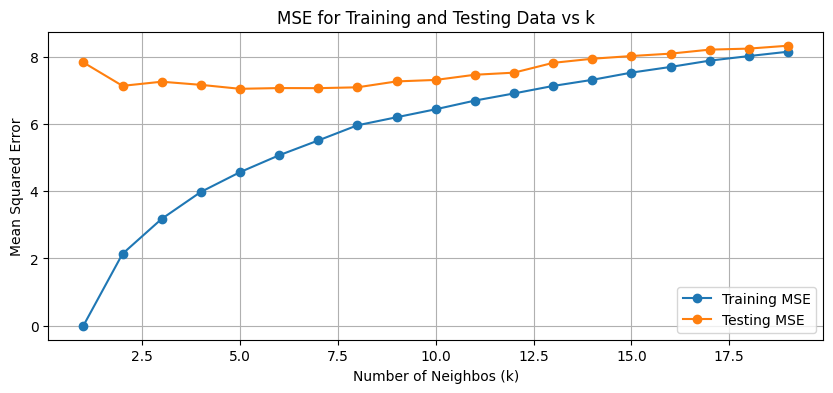

In [502]:
train_mse = [] 
test_mse = [] 

k_values = range(1,20) 
for k in k_values: 
    knn = KNeighborsRegressor(n_neighbors = k, n_jobs = 1) 
    knn.fit(x_train_scaled, y_train) 
    y_train_pred = knn.predict(x_train_scaled) 
    y_test_pred = knn.predict(x_test_scaled) 
    train_mse.append(mean_squared_error(y_train, y_train_pred)) 
    test_mse.append(mean_squared_error(y_test, y_test_pred)) 

plt.figure(figsize = (10,4)) 
plt.plot(k_values , train_mse ,label = 'Training MSE' , marker = 'o') 
plt.plot(k_values, test_mse , label = 'Testing MSE', marker = 'o') 
plt.xlabel('Number of Neighbos (k)') 
plt.ylabel('Mean Squared Error') 
plt.title('MSE for Training and Testing Data vs k') 
plt.legend() 
plt.grid() 
plt.show()
    

# SVR Model

In [471]:
from sklearn.svm import SVR 
model1svr = SVR() 
model1svr.fit(x_train_scaled, y_train)

,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm.If none is given, 'rbf' will be used. If a callable is given it isused to precompute the kernel matrix.For an intuitive visualization of different kernel typessee :ref:`sphx_glr_auto_examples_svm_plot_svm_regression.py`",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.The penalty is a squared l2. For an intuitive visualization of theeffects of scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"epsilon epsilon: float, default=0.1Epsilon in the epsilon-SVR model. It specifies the epsilon-tubewithin which no penalty is associated in the training loss functionwith points predicted within a distance epsilon from the actualvalue. Must be non-negative.",0.1
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False
,"max_iter max_iter: int, default=-1Hard limit on iterations within solver, or -1 for no limit.",-1


In [472]:
y_pred_svr = model1svr.predict(x_test_scaled)


In [473]:
evaluate_model(y_test, y_pred_svr)

{'Mean squared error': 6.883454364402487,
 'Mean Absoluter error': 6.883454364402487,
 'Root mean squared error': np.float64(2.6236338091285694),
 'R2 score': 0.9204219430473749}

# Decision Tree Regression

In [474]:
from sklearn.tree import DecisionTreeRegressor 
model1DTR = DecisionTreeRegressor(random_state = 42) 
model1DTR.fit(x_train, y_train)

,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_l

In [475]:
y_pred_dtr = model1DTR.predict(x_test) 

In [476]:
evaluate_model(y_test, y_pred_dtr)

{'Mean squared error': 5.3659385665529005,
 'Mean Absoluter error': 5.3659385665529005,
 'Root mean squared error': np.float64(2.316449560545815),
 'R2 score': 0.9379655995016536}

# Regularization

In [477]:
from sklearn.linear_model import Lasso 
lasso = Lasso(alpha = 0.01) 
lasso.fit(x_train_scaled, y_train) 
print("Lasso coefficients") 
for feature, coeff in zip(x.columns, lasso.coef_):
    print(f"{feature} : {coeff:.4f}")

Lasso coefficients
Country : 7.8984
Status : 0.0560
AdultMortality : 0.1373
infantdeaths : 0.1146
Alcohol : -0.3091
percentageexpenditure : 0.0754
HepatitisB : -0.5631
Measles : -0.2151
BMI : -0.0373
under-fivedeaths : -0.1949
Polio : 0.0272
Totalexpenditure : 0.1023
Diphtheria : 0.5321
HIV/AIDS : -0.4954
GDP : -0.0306
Population : 0.0935
thinness1-19years : -0.0000
thinness5-9years : -0.0467
Incomecompositionofresources : 0.8325
Schooling : 0.0883


# Feature Selection

In [478]:
selected_features = x.drop(columns = ['Country'], errors = 'ignore')
selected_features.head()

,Status,AdultMortality,infantdeaths,Alcohol,percentageexpenditure,HepatitisB,Measles,BMI,under-fivedeaths,Polio,Totalexpenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness1-19years,thinness5-9years,Incomecompositionofresources,Schooling
0,0,263.0,30.407445,0.01,71.279624,65.0,2427.855874,19.1,42.179303,82.655055,8.16,65.0,0.1,584.259210,1.231209e+07,4.850502,4.881301,0.479,10.1
1,0,271.0,30.407445,0.01,73.523582,62.0,492.000000,18.6,42.179303,58.000000,8.18,62.0,0.1,612.696514,3.275820e+05,4.850502,4.881301,0.476,10.0
2,0,268.0,30.407445,0.01,73.219243,64.0,430.000000,18.1,42.179303,62.000000,8.13,64.0,0.1,631.744976,1.231209e+07,4.850502,4.881301,0.470,9.9
3,0,272.0,30.407445,0.01,78.184215,67.0,2427.855874,17.6,42.179303,67.000000,8.52,67.0,0.1,669.959000,3.696958e+06,4.850502,4.881301,0.463,9.8
4,0,275.0,30.407445,0.01,7.097109,68.0,2427.855874,17.2,42.179303,68.000000,7.87,68.0,0.1,63.537231,2.978599e+06,4.850502,4.881301,0.454,9.5


In [479]:
x = selected_features 
y = df['Lifeexpectancy'] 

In [480]:
from sklearn.model_selection import train_test_split 
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size = 0.2, random_state = 42)


In [481]:
#Linear Regression 
lasso_model1LR = LinearRegression() 
lasso_model1LR.fit(x_train_scaled, y_train) 
y_pred_lasso = lasso_model1LR.predict(x_test_scaled) 
evaluate_model(y_test, y_pred_lasso)

{'Mean squared error': 5.898657218852803,
 'Mean Absoluter error': 5.898657218852803,
 'Root mean squared error': np.float64(2.4287151374446534),
 'R2 score': 0.9318069598117212}

In [482]:
#KNN Regression
lasso_modelKNN = KNeighborsRegressor(n_neighbors = 5
                                     , n_jobs = -1) 
lasso_modelKNN.fit(x_train_scaled, y_train) 
y_pred_knn = lasso_modelKNN.predict(x_test_scaled) 
results = evaluate_model(y_test,y_pred_knn ) 
r1_lr = results['R2 score'] 
print(r1_lr)



0.9185356323464429


In [483]:
#SVR 
lasso_modelSVR = SVR() 
lasso_modelSVR.fit(x_train_scaled, y_train) 
y_pred_svr = lasso_modelSVR.predict(x_test_scaled) 
evaluate_model(y_test, y_pred_svr)

{'Mean squared error': 6.883454364402487,
 'Mean Absoluter error': 6.883454364402487,
 'Root mean squared error': np.float64(2.6236338091285694),
 'R2 score': 0.9204219430473749}

In [484]:
# Decision Tree Regression 
lasso_modelDTR = DecisionTreeRegressor(random_state = 42) 
lasso_modelDTR.fit(x_train, y_train) 
y_pred_dtr = lasso_modelDTR.predict(x_test) 
evaluate_model(y_test, y_pred_dtr)

{'Mean squared error': 7.593856655290103,
 'Mean Absoluter error': 7.593856655290103,
 'Root mean squared error': np.float64(2.7556953124919494),
 'R2 score': 0.9122091430532491}

# Hyperparameter Tuning

In [485]:
from sklearn.model_selection import GridSearchCV

In [486]:
param_grid = {
    'max_depth' : [3,5,10,None],
    'min_samples_split': [2,5,10],
    'min_samples_leaf': [1,2,4],
    'max_features': [None, 'sqrt', 'log2'] 

}

In [487]:
dt = DecisionTreeRegressor(random_state = 42) 
grid_search = GridSearchCV(estimator = dt, param_grid = param_grid, cv = 5, scoring = 'neg_mean_squared_error',verbose = 1, n_jobs = -1) 
grid_search.fit(x_train, y_train)

Fitting 5 folds for each of 108 candidates, totalling 540 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeR...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [3, 5, ...], 'max_features': [None, 'sqrt', ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time 

In [488]:
print("Best Parameters: ", grid_search.best_params_) 
best_dt = grid_search.best_estimator_ 
y_pred_grid_dt = best_dt.predict(x_test) 
evaluate_model(y_test, y_pred_grid_dt)

Best Parameters:  {'max_depth': 10, 'max_features': None, 'min_samples_leaf': 4, 'min_samples_split': 2}


{'Mean squared error': 6.532764293249938,
 'Mean Absoluter error': 6.532764293249938,
 'Root mean squared error': np.float64(2.5559272863776736),
 'R2 score': 0.9244761915362177}

In [489]:
results = evaluate_model(y_test, y_pred_grid_dt) 
r2_dtr = results['R2 score']
print(r2_dtr)

0.9244761915362177


# KNN

In [490]:
knn_params = {
    'n_neighbors': [5,7,19,25],
    'weights': ['uniform','distance'],
    'metric' : ['euclidean', 'manhattan', 'minkowski'] 
}

In [491]:
knn = KNeighborsRegressor() 
grid_knn = GridSearchCV(knn,knn_params, cv = 5, scoring = 'neg_mean_squared_error', n_jobs = -1, verbose = 1) 
grid_knn.fit(x_train_scaled, y_train)

Fitting 5 folds for each of 24 candidates, totalling 120 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",KNeighborsRegressor()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'metric': ['euclidean', 'manhattan', ...], 'n_neighbors': [5, 7, ...], 'weights': ['uniform', 'distance']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter cand

In [492]:
print("Best Parameters: ", grid_knn.best_params_) 
best_knn = grid_knn.best_estimator_ 
y_pred_grid_knn = best_knn.predict(x_test_scaled) 
evaluate_model(y_test, y_pred_grid_knn)

Best Parameters:  {'metric': 'manhattan', 'n_neighbors': 5, 'weights': 'distance'}


{'Mean squared error': 4.076643616799269,
 'Mean Absoluter error': 4.076643616799269,
 'Root mean squared error': np.float64(2.019069988088394),
 'R2 score': 0.9528708464182042}

In [493]:
results = evaluate_model(y_test, y_pred_grid_knn) 
r3_knn = results['R2 score'] 
print(r3_knn)

0.9528708464182042


# SVR

In [494]:
svr_params =  {
    'kernel': ['linear', 'rbf'],
    'C': [0.1,1,10],
    'epsilon': [0.1,0.2,0.5,1.0] 
}

In [495]:
svr = SVR() 
grid_svr = GridSearchCV(svr, svr_params,  cv = 5, scoring = 'neg_mean_squared_error', n_jobs = -1, verbose = 1) 
grid_svr.fit(x_train_scaled, y_train)

Fitting 5 folds for each of 24 candidates, totalling 120 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",SVR()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': [0.1, 1, ...], 'epsilon': [0.1, 0.2, ...], 'kernel': ['linear', 'rbf']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also di

In [496]:
print("Best SVR Parameters: ", grid_svr.best_params_)

Best SVR Parameters:  {'C': 10, 'epsilon': 0.2, 'kernel': 'rbf'}


In [497]:
best_svr = grid_svr.best_estimator_ 
y_pred_svr = best_svr.predict(x_test_scaled) 
evaluate_model(y_test, y_pred_svr)

{'Mean squared error': 4.266407287223639,
 'Mean Absoluter error': 4.266407287223639,
 'Root mean squared error': np.float64(2.065528331256591),
 'R2 score': 0.9506770316018143}

In [498]:
results = evaluate_model(y_test, y_pred_svr) 
r4_svr = results['R2 score'] 
print(r4_svr)

0.9506770316018143


Text(0.5, 1.0, 'Comparison of Model Scores')

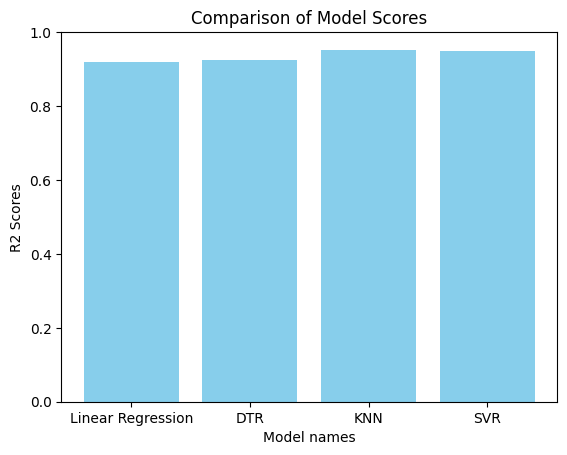

In [501]:
model_names = ['Linear Regression', 'DTR', 'KNN', 'SVR'] 
model_scores = [r1_lr, r2_dtr, r3_knn, r4_svr] 
plt.bar(model_names, model_scores, color = 'skyblue') 
plt.xlabel('Model names') 
plt.ylabel('R2 Scores') 
plt.title('Comparison of Model Scores')

In [ ]:
from sklearn.pipeline import Pipeline 
